# Lesson 182 · RDB-PFN + composite message passing

Mirror scope: complete selected published-checkpoint evaluation and the RelGNN one-head composite equation. Tier B: all fresh F1 predictions and hashed inputs. Tier C: controlled route arithmetic and fabricated factorial examples. Default notebook execution replays evidence and runs the visible model on a small input; the author ran all30fresh evaluations separately. New hybrid pretraining is NOT_RUN.

Requires Python3, NumPy and PyTorch. Images, evidence, source and one real checkpoint are embedded; default execution needs no repository clone or network.

In [1]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
from pathlib import Path
import json,copy,hashlib,base64,io,zipfile
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
torch.set_num_threads(1)
print("Default: complete saved-evidence rescore + live mechanism. Fresh inference is an opt-in after EXIT.")

Default: complete saved-evidence rescore + live mechanism. Fresh inference is an opt-in after EXIT.


**Your win:** turn “combine these two papers” into a precise intervention, a fair comparison, and a result that could prove your idea wrong. The core reading is one session; use a second for the notebook and written defense.

**Observed:** fresh complete selected reproduction: **30 evaluations, 21,060 predictions**, all three means round to their published targets. New hybrid training **NOT_RUN**; whole-paper reproduction **NOT_RUN**. Learner **PENDING_WRITTEN_DEFENSE**.

[Student notebook](https://avistian.github.io/relational/labs/0182-rdb-pfn-composite-message-passing.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0182-rdb-pfn-composite-message-passing.html) · [Solution notebook](https://avistian.github.io/relational/labs/solutions/0182-rdb-pfn-composite-message-passing.ipynb) · [Quick reference](https://avistian.github.io/relational/reference/rdb-pfn-composite-message-passing.html) · [Full protocol](https://avistian.github.io/relational/labs/l182-reproduction.md).

## 1 · First name what will change

[Lesson 181](https://avistian.github.io/relational/lessons/0181-relbench-v2-autocomplete.html) turned a missing-cell prediction into a task contract: identify the row, hide unavailable answers, and score the complete population. Its GNN training stopped at a gradient-health prerequisite. That unfinished experiment stays unfinished here. We now ask a different question: **what would make a combination of two existing methods worth testing?**

Recall the two building blocks. A **prior** is a distribution of possible tasks. RDB-PFN trains on synthetic tables and relational databases sampled from such a distribution. At deployment, it receives labeled **support examples** and unlabeled **queries**. In-context learning, or **ICL**, predicts queries from that support while model weights remain fixed. RelGNN is a graph model that routes information through foreign-key relationships. Its **composite message** combines a source row and an intermediate row before the destination aggregates them. [RDB-PFN §§4–5](https://arxiv.org/html/2603.03805v5), [RelGNN §4](https://arxiv.org/html/2502.06784v2).

> **In plain terms.** One paper changes what the model practices on. The other changes how relational information reaches a prediction. Those changes could complement each other, overlap, or conflict.

A **hypothesis** makes a prediction under specified conditions. “Relational prior plus composite routes will win” leaves too much unspecified. Which component changes? Which information is held fixed? What observation would make us abandon the idea?

## 2 · Model architecture: two insertion points, two experiments

### The published RDB-PFN path

During pretraining, a generator samples a schema, foreign-key structure, and table contents. A **schema** states table types and their relationships. A **foreign key** identifies the parent row referenced by a child row. Deep Feature Synthesis (**DFS**) converts relational neighborhoods into tabular attributes using operations such as counts and means. A Transformer predicts hidden query labels from the other labeled rows. Training adjusts its weights using query-label loss. [RDB-PFN §5 and Appendix C](https://arxiv.org/html/2603.03805v5#S5).

During the released evaluation, the relational database has already been converted to a feature matrix. For one support draw, concatenate 512 labeled support rows and 702 query rows. The numeric encoder projects each scalar feature into width 96. Six blocks alternate feature attention within a row and support-row attention for each feature. A label token carries support labels; a binary decoder produces two query logits, converted to probabilities. An **MLP** is a feed-forward network applied to a token; a **residual** adds its input back to its transformed output. A **logit** is an unnormalized prediction score. No query label or entity identifier enters this model. The labels enter only through support. The released base model has 692,738 parameters. [Visible implementation](https://avistian.github.io/relational/labs/relkit/rdbpfn_l166.py), [original model](https://avistian.github.io/relational/labs/sources/l166/upstream/model_pretrain/src/models.py).

**Shapes.** Let F be the number of released DFS features. The input has shape 1 × 1,214 × F: one task, 1,214 rows, F columns. Feature tokens have shape 1 × 1,214 × F × 96; the label token adds one token per row. The decoder returns 1 × 702 × 2 logits. Chunking is disabled in practice because all 702 queries fit below the source chunk limit of 2,000.

> **Scope check.** The paper appendix describes width 128; the released numeric checkpoints use width 96. We reproduce the released weights and code. Their source/data identity is pinned; historical experiment identity remains unestablished.

<figure class="route-figure" tabindex="0">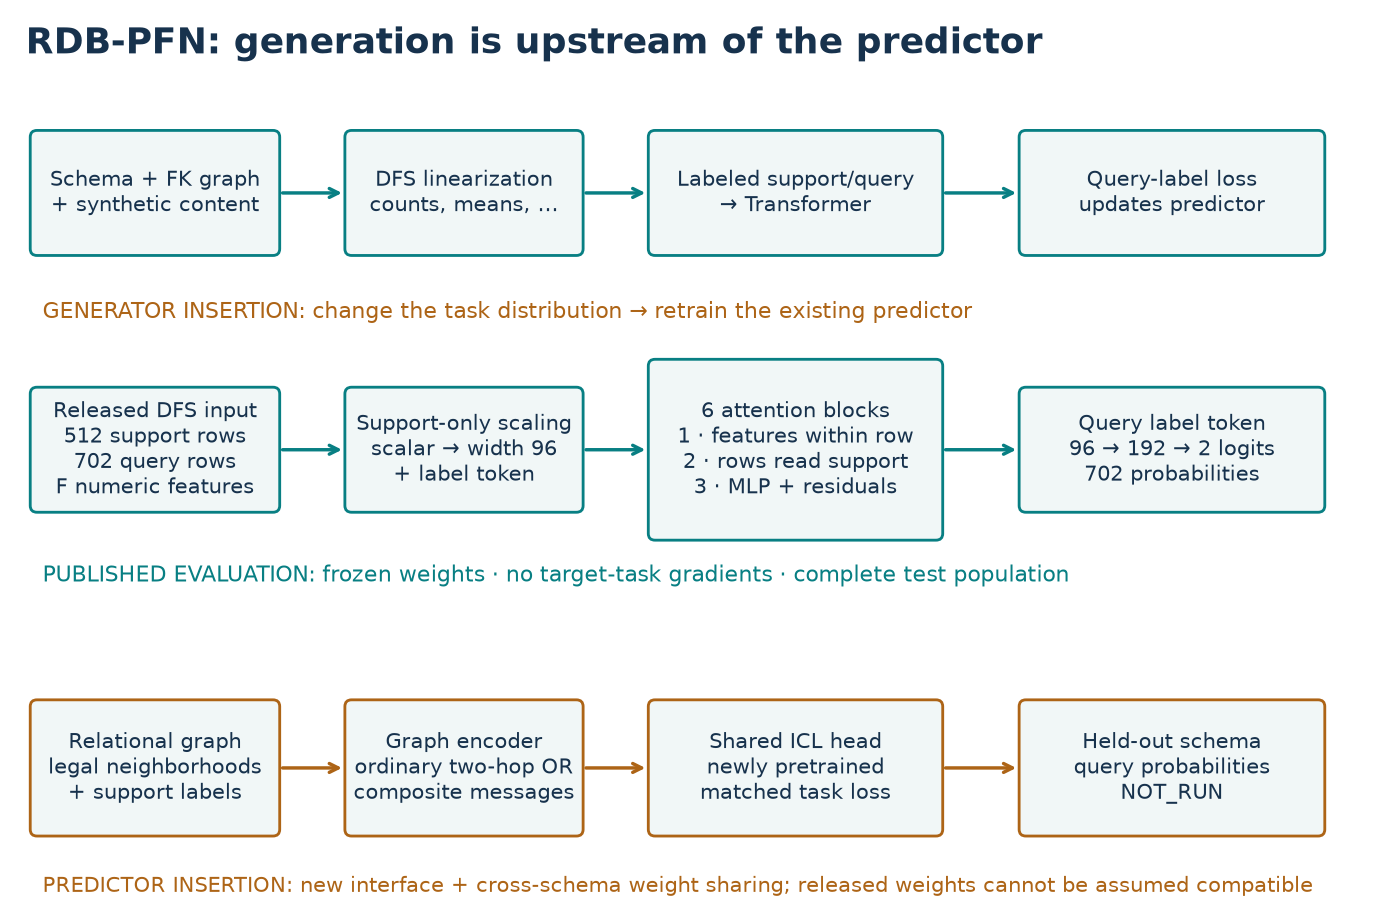<figcaption>Three complete paths: published synthetic pretraining, frozen released-checkpoint inference, and a proposed graph encoder plus ICL head. The two insertion points require different new training experiments.</figcaption></figure>

### Generator-side proposal

Change the operator that creates synthetic relational contents or targets, while keeping DFS and the predictor architecture fixed. This changes the tasks sampled during pretraining. The released generator already has a configurable row-GNN path; “add a GNN” alone is not a distinct proposal. One must specify the changed message equation, how it changes label dependencies, and what existing generator behavior it replaces. [Released generation code](https://avistian.github.io/relational/labs/sources/l166/upstream/data_generation/RDB/src/prior/row_gnn.py).

### Predictor-side proposal

Keep synthetic training tasks fixed and replace the representation step with a graph encoder using composite messages. Follow that encoder with a shared support/query ICL head. **This needs new training.** The released RDB-PFN checkpoint learned a DFS feature interface; a new graph embedding with the same vector width does not automatically preserve its meaning.

An encoder must also work across schemas. RelGNN's source uses separate weights for atomic routes in a fixed schema. A cross-database model needs an explicit rule for sharing weights across unfamiliar table names and routes. Parameter sharing means deciding which computations use the same learned matrices. Matching dimensions alone does not solve that problem.

> **Scope check.** Both hybrid paths are proposals. Neither is a published combination reproduced here. The full original RDB-PFN model and RelGNN operator are visible in the notebook; the fresh numerical reproduction below evaluates the existing RDB-PFN models.

## 3 · Trace one composite message

An **atomic route** connects a source and destination either directly or through an intermediate table with multiple foreign keys. Consider **product → purchase → customer**. Each purchase refers to one product and one customer. The purchase is the bridge; its quantity is meaningful together with the product it references. [RelGNN §4.1–4.3](https://arxiv.org/html/2502.06784v2#S4).

**Worked example.** Two legal purchases produce source vectors [1, 0] and [0, 1]. Their bridge vectors are [0, 1] and [2, 0]. With identity projection matrices, fuse each source with its own bridge:

- First purchase: [1, 0] + [0, 1] = **[1, 1]**.
- Second purchase: [0, 1] + [2, 0] = **[2, 1]**.

The customer query is [1, 0]. A dot product measures how well each fused message aligns with it. Divide by √2 because each vector has two coordinates: the scores are 0.7071 and 1.4142. **Softmax** exponentiates scores and normalizes them to sum to one. The weights become 0.3302 and 0.6698. Their weighted sum is **[1.6698, 1.0000]**.

<figure class="route-figure" tabindex="0">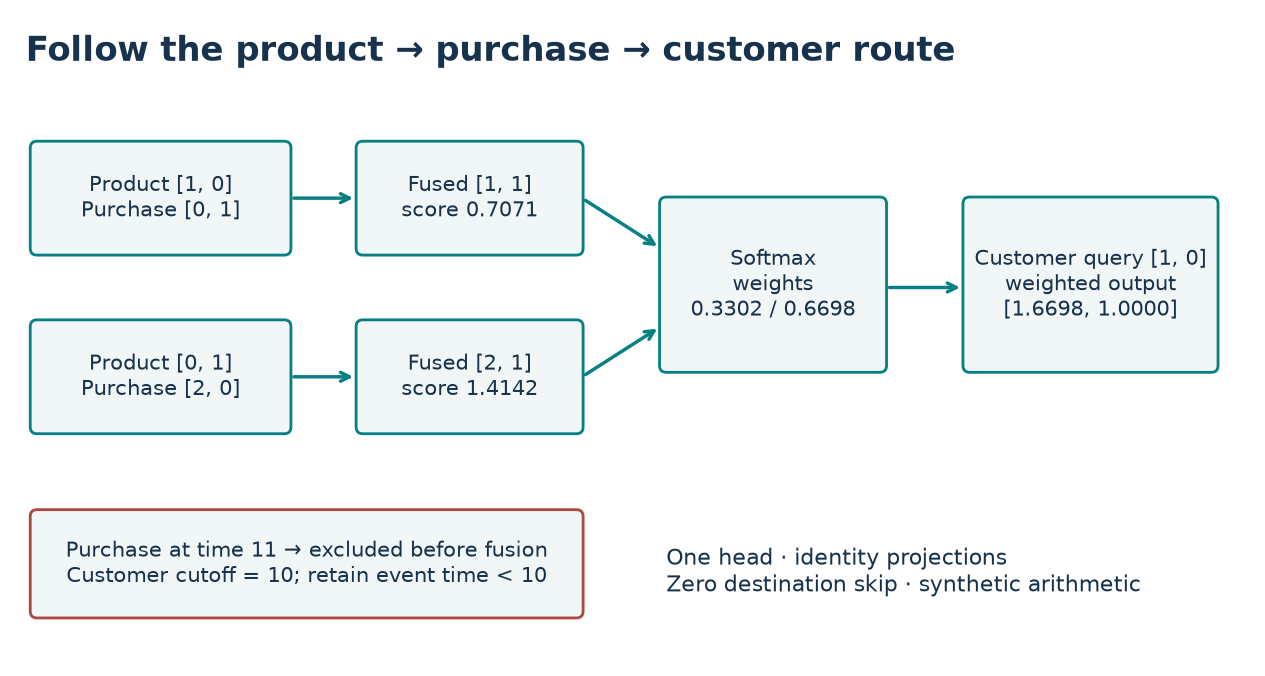<figcaption>Synthetic one-head composite calculation with identity projections and zero destination skip. A future purchase is excluded before fusion; the remaining output is [1.6698, 1.0000].</figcaption></figure>

For general vectors, fusion is `z_j = W_source h_source(j) + W_bridge h_bridge(j)`. Here j indexes a bridge row and source(j) is its foreign-key parent. The W matrices are learned linear maps. Destination i receives `sum_j alpha_ij V z_j`; alpha is softmax of `(Q h_i)·(K z_j)/sqrt(d)` over legal messages to i. Q, K and V are query, key and value projections; d is the width of one head. A **head** is one separately parameterized attention calculation. RelGNN uses multiple heads plus output projection and destination skip; our transparent worked kernel uses one head, identity projections and zero skip.

**Before fusion:** resolve each foreign key and enforce the destination's cutoff. Our course experiment retains a dated event only when `event_time < receiver_cutoff`. Different receivers may have different cutoffs. Filtering by the latest cutoff in a batch could admit a future event for an earlier receiver. This policy connects the mechanism to Lesson 181's information contract.

> **Scope check.** The one-head state matches the original RelGNN operator under the stated weights; its input derivatives also match finite differences. That validates this specialization, not an entire trained graph model or historical availability.

## 4 · Try to break the mechanism

Predict before running: does duplicating only one legal message preserve softmax attention? Write your reason.

In the live notebook below, compare baseline, permuted, future-value-changed, duplicated and merged-route states. Predict the unchanged states before executing.

**Held fixed:** query [1, 0], identity projections, route definition, cutoff 10. **Changed:** row order, an excluded future value, message multiplicity, or the route membership. **Measured:** the two output coordinates and attention weights. These interventions isolate different behaviors; none measures prediction accuracy.

Permuting the two legal rows leaves the output unchanged. Changing a future purchase dated 11 also leaves it unchanged because the row is filtered out first. Duplicating the first legal message changes the result to [1.5035, 1.0000]. Softmax is invariant to order, not to duplicating just one member. Adding another route's [8, 0] vector into the same normalization changes the result to [7.8670, 0.0210]. This deliberately violates route separation.

**Preserving rows is different from preserving their relationships.** Swap which product each of the two legal purchase rows references, keeping the same source and bridge vectors. This is a foreign-key intervention, not a reordering of intact records:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Pairing</th><th>Fused messages</th><th>Attention output</th></tr></thead><tbody><tr><td>Original</td><td>[1,1]; [2,1]</td><td>[1.6698, 1.0000]</td></tr><tr><td>Product links swapped</td><td>[0,2]; [3,0]</td><td>[2.6789, 0.2141]</td></tr></tbody></table>

Both sets have arithmetic mean `[1.5,1]`, but their query-dependent attention outputs differ. The joint source–bridge pairing matters even when separate averages are unchanged. **Transfer check:** reverse the order of both intact fused messages and their destination indices. The original attention output must stay unchanged. Swapping only the product links changes the database; permuting intact records changes its storage order.

That last result is **not proof that every ordinary GNN destroys useful information**. Another message-passing architecture might preserve roles. The experiment explains why role mixing is worth controlling, rather than proving a universal expressive advantage.

## 5 · Establish the published result before proposing its extension

Our named target is **RDB-PFN v5 Table 9, rel-f1/driver-dnf, context size 512**. Three models use the same ten support draws and every one of the 702 test queries. We ran all 30 evaluations freshly, with fixed released checkpoints and all 32 TabICL ensemble estimators. An **ensemble** combines several model evaluations into one prediction. Source hashes, selected supports and complete `(driverId, date)` identities were checked before scoring. [Frozen protocol](https://avistian.github.io/relational/labs/l182-reproduction.md), [paper Table 9](https://arxiv.org/html/2603.03805v5#A6).

**AUROC** measures the fraction of positive/negative pairs in which the positive gets a higher predicted probability, giving half credit to ties. It ranges from zero to one; higher is better. We calculate it directly from pairs and independently with scikit-learn. The largest difference is below 1.12 × 10⁻¹⁶.

| Released model | Fresh mean AUROC ± sample SD | Paper target |
|---|---:|---:|
| RDBPFN | 0.721938 ± 0.019983 | 0.7219 |
| RDBPFN_single | 0.663990 ± 0.034177 | 0.6640 |
| TabICLv1.1 | 0.717568 ± 0.009770 | 0.7176 |

All three pass the predeclared descriptive mean-distance tolerance 0.02. This tolerance is not a statistical equivalence test.

<figure class="route-figure" tabindex="0">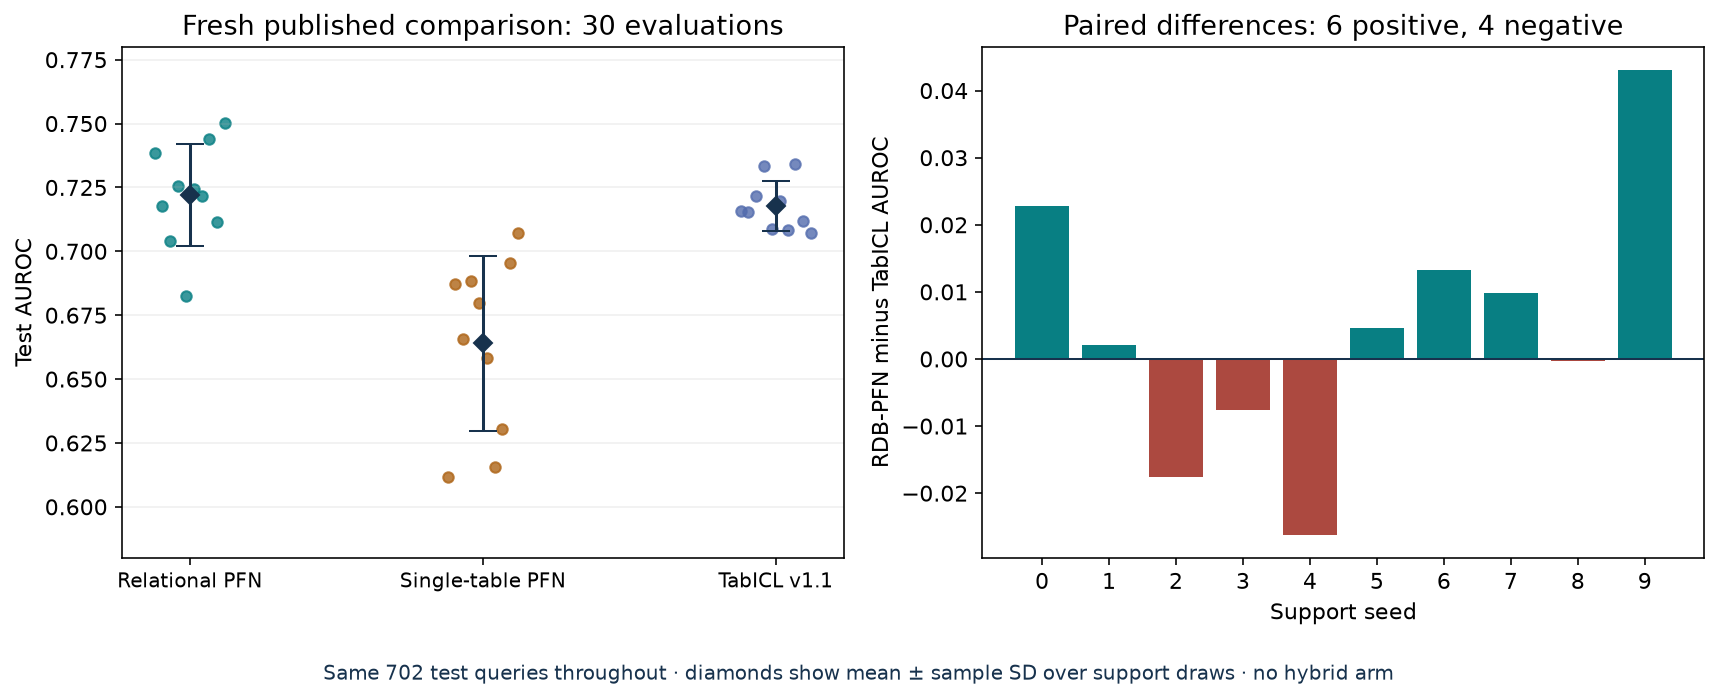<figcaption>Fresh full selected experiment. Ten support draws per model share one test population. Points show each draw; diamonds and bars show mean and sample SD, not confidence intervals.</figcaption></figure>

The mean difference between relational and single-table RDB-PFN is **+0.05795 AUROC**, positive for all ten support draws. These checkpoints share the released predictor architecture. They differ in training history, so the result does not isolate a new message operator. The RDB-PFN–TabICL difference is much smaller: **+0.00437**, positive in six of ten draws and negative in four. TabICL is a separate model family, not the “composite” arm of a controlled experiment.

**What the uncertainty means.** Sample standard deviation describes variation when choosing different support rows for this same task. Ten draws share the same test set. They are not ten independent databases, and a fresh rerun of L166 is not a new data replication. Every fresh probability here exactly matches the corresponding L166 probability; that is observed repeatability in this environment.

> **Scope check.** The release labels are the complement of the current raw DNF definition. Preserve that convention to reproduce the table; complement both labels and probabilities to interpret current DNF risk. Full raw DFS regeneration and historical feature availability remain unestablished. Reproducing numerical scores does not certify deployability or whole-paper parity.

## 6 · A hypothesis that can lose

**Candidate hypothesis:** under a fixed synthetic-task and labeled-support budget, a relational prior benefits more from a composite graph encoder than from conventional two-hop message passing, especially on held-out bridge-heavy schemas.

A **held-out schema** has a table/relationship structure excluded from model selection. “Bridge-heavy” must be defined before seeing results—for example, a specified fraction of query-relevant dependencies passing through tables with multiple foreign keys. Cross-schema weight sharing must be fixed first. Otherwise a gain could come from extra schema-specific parameters.

The proposed predictor experiment has four arms. Every arm uses the same ICL head and task loss. The prior changes the training-task distribution; the encoder changes the message rule. All four models need fresh training. Pair generator seeds, task counts, support draws and evaluation queries where meaningful, and disclose parameter and measured-compute differences. Include a second comparison at matched compute if composite and conventional encoders have different costs.

| Arm | Synthetic training prior | Encoder before the shared ICL head |
|---|---|---|
| A | Single-table prior | Conventional two-hop graph encoder |
| B | Single-table prior | Composite graph encoder |
| C | Relational prior | Conventional two-hop graph encoder |
| D | Relational prior | Composite graph encoder |

In the single-table prior arms, there are no inter-table edges during pretraining; the same input interface must handle this degenerate graph. That creates a transfer challenge by design. Record which relational parameters receive training signal, rather than pretending every parameter was equally exercised. A route-preserving relational-prior control would be an additional experiment, not a hidden replacement for these arms.

<figure class="route-figure" tabindex="0">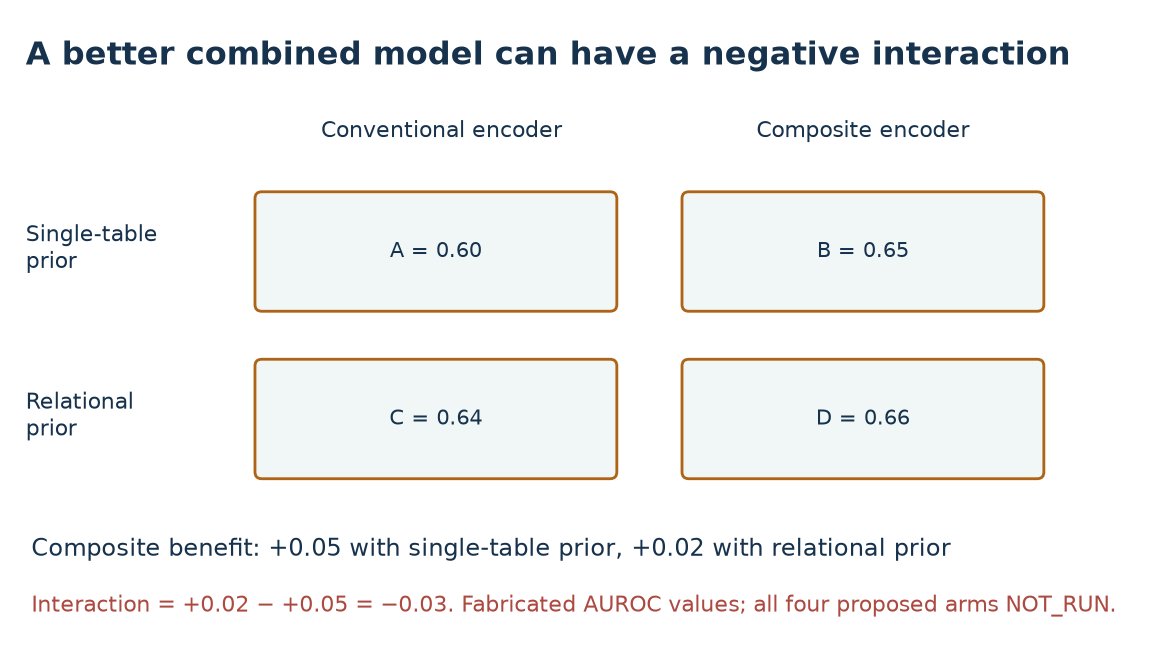<figcaption>Fabricated four-arm AUROC example. D is best but the paired interaction is negative. No proposed hybrid arm was trained.</figcaption></figure>

**Interaction** asks whether one change alters the benefit of another. For each paired seed, compute `(D − C) − (B − A)`. A positive value supports complementarity on that measurement. D beating A alone is insufficient.

**Worked example—fabricated numbers.** A = 0.60, B = 0.65, C = 0.64, D = 0.66. The combined model D is best, yet its interaction is `(0.66−0.64)−(0.65−0.60) = −0.03`. Composite messages helped less with the relational prior in this illustration. These are arithmetic examples, not trained results.

**Falsification test 1: no complementary effect.** Predeclare a minimum useful interaction and evaluate it on untouched tasks across at least three databases. If uncertainty remains too large to distinguish it, call the result inconclusive. If the upper uncertainty bound falls below that threshold, the proposed useful complementarity is unsupported. Compute task-level paired contrasts; do not treat all query rows or support seeds as independent database samples.

**Falsification test 2: the fair control closes the gap.** Give the conventional model the same legal neighborhood, effective receptive field, supervision and tuning allowance. If its performance matches the composite model within a predeclared practical margin at comparable compute, withdraw the claim that composite routing is responsible. Log whether differences come from missing data, parameter count, training stability or exposure to additional labels.

Generator-side changes would need a separate contrast with the predictor fixed. Testing both insertion points at once would make any result hard to attribute.

## 7 · Implement, inspect, defend

The notebook has three live tasks: fuse only legal route rows, score the complete key set, and compute paired factorial interactions. Your functions feed the mechanism experiment and the full 30-run rescore. Wrong implementations are rejected. The original model, checkpoint evaluator and composite source appear inline for inspection; a separate opt-in runs fresh checkpoint inference.

Write your hypothesis and falsification criteria in the EXIT ticket below, then ask the teaching agent to review them.

**EXIT:** name your insertion point, what stays fixed, what must be retrained, what the published evidence establishes, and the two results that would make you abandon the proposal. Ask the teaching agent follow-up questions about any unclear step; paste your defense for review. Passing code alone does not award mastery.

**Primary reading:** RDB-PFN §5.2 and Appendix C.2, then RelGNN §4.2–4.3. Trace the point at which the source architecture sees a flattened feature matrix versus foreign-key edges. Next, Lesson 183 investigates Graph-Transformers and pretraining; keep the same intervention-and-control discipline.

> **Scope check.** Selected released-checkpoint reproduction COMPLETE; new hybrid training and whole-paper reproduction NOT_RUN. L180's practical exit and L181's stopped GNN experiment remain unchanged. Live Colab and deployment are separate checks.

**Next: [Lesson 183](https://avistian.github.io/relational/lessons/0183-graph-transformer-pretraining.html).** Keep the four-arm comparison, but change the question: does prior training help one backbone more than another? A promising composite route does not answer that initialization question.


## PROVIDED · Authenticate the portable packet
The payload contains all30fresh prediction files as records, the prepared real dataset, one checkpoint, and pinned model/evaluation source. Authentication precedes scoring. The large string is data, not hidden model logic.

In [2]:
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='f15e100b641c96a879e9dc0a44fb8c2a8cf5914a1c9c55192d12cf11b73ced1e'
P=Path("l182-packet");P.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():
        assert not Path(name).is_absolute() and ".." not in Path(name).parts
    z.extractall(P)
hashes={'RDBPFN.pt': 'ea9aa1bfbea5fa3fb8d88a043d7b8b5eb0e191dc4049e3e2a89822318e134bfb', '_run_l166.py': '80c5617efd0615abefbd9016166469fee58a39c95f853349c3edc675c5b06497', 'input-manifest.json': '76d0c10a4f083136dfac5254e57788770381887443b722e47ff9484998206b1f', 'pfn-parity.json': '9c40c283b63b7c70d5f61930abb9a427defdd182eab168c89f278b2690ffda0c', 'predictions.json': '27a71a39f95e50bed5a363883419562b98ffb07a8fa78a08fff6dcace1277735', 'prepared.npz': '9f4a0e9245420127c6391196bdc1a33dba4bbb88bdf3e42161912e3763a20bbe', 'source/model_pretrain/LimiX/inference/inference_method.py': 'd8c1af09b368ca8fa4848c2dd6fe325b55e7187c76d81d88fd2bfee94a723f50', 'source/model_pretrain/LimiX/inference/predictor.py': 'f67024c5a3a49a26eb65b4928609fd17d2bd33bf4dce0aba093c639b4c72160a', 'source/model_pretrain/LimiX/inference/preprocess.py': 'cbe090a764a1bd172292963f22eea5e352bf2e19c5c1e2df921f638dee841afd', 'source/model_pretrain/LimiX/model/encoders.py': 'ecd635207cce4463c8178edbfc65b60e1e47451acfd8c800d844a2d3c7f178c8', 'source/model_pretrain/LimiX/model/layer.py': '89d59efad408a3f8ba5b19849ac37653295d9b63b749eeef3b63daec808e9bb5', 'source/model_pretrain/LimiX/model/transformer.py': '8d3682d1e871beffed2f0b6c56b2cbd7cc07c17e4a6f9f8ad449d0b79b2b5290', 'source/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/inference_search.py': 'd5946468b964ed76ad1b44e6528f40598c44ad7dbc61e0ac3beadef6d97539c8', 'source/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/init_search_space.py': '507b92a87f617ea49453c81ce478f12e29fb0d74af38ca1496b1098425d6df5f', 'source/model_pretrain/LimiX/utils/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'source/model_pretrain/LimiX/utils/data_utils.py': '996071624a314e2677c4c0f64ed069890d6b37ce7286841eaee2a9885805521d', 'source/model_pretrain/LimiX/utils/inference_utils.py': 'fd8b9b145248d41930fec26759275d3d1bfec26f0bddcc8c96ca81ab6f6f43f0', 'source/model_pretrain/LimiX/utils/loading.py': '93f0b72009e6656bc4969d7732eaa0c18cf2f74c502fef1835091acb1f58a20e', 'source/model_pretrain/LimiX/utils/retrieval_utils.py': '68d1d46913b0d382266c5e60db82327cb8494d801799870f5599673657b9a3a2', 'source/model_pretrain/LimiX/utils/utils.py': 'b5fb621316d0669e40aed0fef1f2b956d4fd907eb5101b0af9049bff229fb60f', 'source/model_pretrain/src/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'source/model_pretrain/src/dataloaders.py': '2547265376ec7c67b0fccc8dba3d638819de36fbe646aa3d0bdbc8d2e4b2e994', 'source/model_pretrain/src/dbinfer_bench_simplified/__init__.py': 'eff64c5d2d1f6613ed8b6f3d10fb68236091d11427585207a136c028a32ca88d', 'source/model_pretrain/src/dbinfer_bench_simplified/dataset_meta.py': 'ca8996e74d537014acb0f11decd10750651a98cdbeae7f2460c3d7a01c75afcf', 'source/model_pretrain/src/dbinfer_bench_simplified/rdb_dataset.py': 'cb28b19ca37dead75f811dc66321bbad762d85c3a36c7b3ea79782e01ea440bd', 'source/model_pretrain/src/dbinfer_bench_simplified/table_loader.py': '521d6ee928d144fee6017b5c286f08144183760597509ff4540d5486fb693f59', 'source/model_pretrain/src/dbinfer_bench_simplified/table_writer.py': 'ed0518963784917b6e35fadb2fdf113036c3fcfc20740a9d04e7d6ba54626ac9', 'source/model_pretrain/src/dbinfer_bench_simplified/yaml_utils.py': '972a1da3a43ffa05f288079ecdabf432c1d4ba3859dbccf25ab1c6cc89bcefe0', 'source/model_pretrain/src/eval.py': 'e4d7330238bfa086c897e9f08b4ad2c2d2e6ff6627cc0c5daa33ea3d04166bc6', 'source/model_pretrain/src/eval_classifiers.py': 'd36a2401e3b238f8dfc79b0e3709bb27f00deeb7b57d5fe38f5862c462f9e128', 'source/model_pretrain/src/eval_csv.py': '9861692da3b6e8b02aa961f9844a8061ed4eb3dfc55d5386d4dba993066e0b26', 'source/model_pretrain/src/eval_utils.py': 'b948fd25b19b743352429935a6eb69bd20282e70f120d3e0f875e2263cc26cc4', 'source/model_pretrain/src/inmemory_dataloader.py': '95fdaee114949a69f1db59302f82ac4b44fb36a3c44eb455bc266e8b636ff7dc', 'source/model_pretrain/src/models.py': '0c64761bca8c484b4fd92ebe129ae4d1420ce1eb9caf46f477690eb81bb07a8b', 'source/model_pretrain/src/train.py': 'b4111470880c43df88ff36ce594ec287cf8f009aa5559a78526cc420dc4c5304', 'source/model_pretrain/src/training.py': 'b129cb095d67364d2f57f79d623e39ef4a49d4f8309eeda92c2efcaa4f623e50', 'source/model_pretrain/src/utils.py': '934218571cd54a23076c5c1eec9112d717a5e2607c24fde066474b3087e72066'}
for name,h in hashes.items():assert hashlib.sha256((P/name).read_bytes()).hexdigest()==h,name
packet=json.loads((P/"predictions.json").read_text())
print(len(packet),"authenticated fresh author evaluation records")

30 authenticated fresh author evaluation records


## TODO · Resolve and filter the route
Return fused messages and destination indices in retained row order. Each bridge row has one source index and one destination index. Keep time strictly less than that receiver cutoff; apply source and bridge matrices. Reject invalid FK indices, nonfinite values and incompatible shapes.

In [3]:
def legal_fusion(source, bridge, source_index, destination_index, times, cutoffs, W_source, W_bridge):
    """One FK-resolved source per bridge; retain events strictly before each owner cutoff."""
    source=np.asarray(source,float);bridge=np.asarray(bridge,float)
    si=np.asarray(source_index);di=np.asarray(destination_index)
    times=np.asarray(times,float);cutoffs=np.asarray(cutoffs,float)
    ws=np.asarray(W_source,float);wm=np.asarray(W_bridge,float)
    if source.ndim!=2 or bridge.ndim!=2 or ws.ndim!=2 or wm.ndim!=2:raise ValueError('Matrices required')
    n=len(bridge)
    if si.shape!=(n,) or di.shape!=(n,) or times.shape!=(n,) or cutoffs.ndim!=1:raise ValueError('Aligned route rows required')
    if si.dtype.kind not in 'iu' or di.dtype.kind not in 'iu':raise ValueError('Integer FK indices required')
    if np.any(si<0) or np.any(si>=len(source)) or np.any(di<0) or np.any(di>=len(cutoffs)):raise ValueError('Unresolved foreign key')
    if ws.shape[0]!=source.shape[1] or wm.shape[0]!=bridge.shape[1] or ws.shape[1]!=wm.shape[1]:raise ValueError('Projection shapes differ')
    if not all(np.isfinite(x).all() for x in [source,bridge,times,cutoffs,ws,wm]):raise ValueError('Finite inputs required')
    keep=times<cutoffs[di]
    return source[si[keep]]@ws+bridge[keep]@wm,di[keep]

### CHECK · Immediate feedback
This small case is necessary; the adversarial and complete-data checks below are stronger.

In [4]:
z,d=legal_fusion(np.array([[1.,0.]]),np.array([[0.,1.],[9.,9.]]),np.array([0,0]),np.array([0,0]),np.array([9.,11.]),np.array([10.]),np.eye(2),np.eye(2))
np.testing.assert_allclose(z,[[1,1]]);np.testing.assert_array_equal(d,[0])
print("Immediate CHECK passed")

Immediate CHECK passed


## TODO · Score the complete population
Join probabilities to labels using both entity and cutoff. Reject duplicate/missing keys, unknown identities, invalid probabilities and single-class truth. Compute positive-negative pair wins with half credit for ties.

In [5]:
def keyed_auc(truth_keys, labels, prediction_keys, probabilities):
    """Pairwise AUROC with half credit for ties, after complete-key alignment."""
    q=[tuple(x) for x in truth_keys];p=[tuple(x) for x in prediction_keys]
    y=np.asarray(labels,float);v=np.asarray(probabilities,float)
    if not q or any(len(k)!=2 for k in q+p) or len(set(q))!=len(q) or len(set(p))!=len(p) or set(q)!=set(p):raise ValueError('Complete unique entity/cutoff keys required')
    if y.shape!=(len(q),) or v.shape!=(len(p),) or not np.isfinite(y).all() or not np.isfinite(v).all() or set(y)!={0.,1.} or np.any((v<0)|(v>1)):raise ValueError('Binary truth and finite probabilities required')
    lookup=dict(zip(p,v));ordered=np.array([lookup[k] for k in q])
    delta=ordered[y==1,None]-ordered[y==0][None,:]
    return float(np.mean((delta>0)+.5*(delta==0)))

### CHECK · Immediate feedback
This small case is necessary; the adversarial and complete-data checks below are stronger.

In [6]:
k=np.array([[1,10],[1,20],[2,20],[3,20]])
y=np.array([0,1,0,1]);p=np.array([.2,.8,.8,.9]);order=[3,1,0,2]
assert keyed_auc(k,y,k[order],p[order])==.875
print("Immediate CHECK passed")

Immediate CHECK passed


## TODO · Test complementarity
Input rows are paired seeds; columns A/B/C/D follow the four-arm table. Return one interaction per row. Require at least two finite AUROC rows and exactly four arms. D minus A is not the required contrast.

In [7]:
def factorial_interaction(scores):
    """Paired seed contrast: (relational+composite minus relational+plain) minus the single-prior difference."""
    x=np.asarray(scores,float)
    if x.ndim!=2 or x.shape[1]!=4 or x.shape[0]<2 or not np.isfinite(x).all() or np.any((x<0)|(x>1)):raise ValueError('At least two paired rows and four AUROC arms required')
    return (x[:,3]-x[:,2])-(x[:,1]-x[:,0])

### CHECK · Immediate feedback
This small case is necessary; the adversarial and complete-data checks below are stronger.

In [8]:
illustration=np.array([[.60,.65,.64,.66],[.61,.66,.65,.67]])
np.testing.assert_allclose(factorial_interaction(illustration),[-.03,-.03])
print("Immediate CHECK passed")

Immediate CHECK passed


## PROVIDED · Attention arithmetic
The load-bearing operation is visible here: dot products, stable softmax, then the weighted sum. The legal-fusion output supplied by your function determines its inputs.

In [9]:
def attend(query, messages, destination):
    """One head with identity Q/K/V projections; zero for an empty neighborhood."""
    query=np.asarray(query,float);messages=np.asarray(messages,float);destination=np.asarray(destination)
    if query.ndim!=2 or messages.ndim!=2 or query.shape[1]!=messages.shape[1] or query.shape[1]<1:raise ValueError('Matching positive widths required')
    if destination.shape!=(len(messages),) or destination.dtype.kind not in 'iu' or np.any(destination<0) or np.any(destination>=len(query)):raise ValueError('Invalid destination')
    if not np.isfinite(query).all() or not np.isfinite(messages).all():raise ValueError('Finite input required')
    result=np.zeros_like(query);weights=np.zeros(len(messages))
    for i,q in enumerate(query):
        idx=np.flatnonzero(destination==i)
        if len(idx):
            logits=messages[idx]@q/np.sqrt(query.shape[1]);w=np.exp(logits-logits.max());w/=w.sum()
            result[i]=w@messages[idx];weights[idx]=w
    return result,weights

## CHECK · Adversarial contracts
These checks exercise duplicate entity IDs at distinct times, invalid foreign keys, receiver-specific cutoffs, probability range, ties and incomplete factorial arms.

In [10]:
def checks(fuse, auc, interaction):
    source=np.array([[1.,2.],[3.,4.]])
    bridge=np.array([[5.,6.],[7.,8.],[9.,10.]])
    args=(source,bridge,np.array([0,1,0]),np.array([0,0,1]),np.array([2.,7.,5.]),np.array([4.,6.]),np.eye(2),2*np.eye(2))
    z,d=fuse(*args)
    np.testing.assert_allclose(z,[[11,14],[19,22]])
    np.testing.assert_array_equal(d,[0,1])
    # Owner cutoff, not batch maximum: event5 for owner0 must be excluded.
    a=list(args);a[4]=np.array([5.,7.,5.]);z,d=fuse(*a)
    np.testing.assert_array_equal(d,[1])
    a=list(args);a[4]=np.array([4.,7.,6.]);z,d=fuse(*a)
    assert z.shape==(0,2) and d.shape==(0,) # Strict before cutoff.
    for index,value in [(2,np.array([0,3,0])),(3,np.array([0,-1,1])),(4,np.array([2.,np.nan,5.]))]:
        a=list(args);a[index]=value
        try:fuse(*a)
        except ValueError:pass
        else:raise AssertionError('Invalid route accepted')
    keys=np.array([[1,10],[1,20],[2,20],[3,20]])
    y=np.array([0,1,0,1]);p=np.array([.2,.8,.8,.9]);order=[3,1,0,2]
    assert auc(keys,y,keys[order],p[order])==.875
    for pk,prob in [(keys[:-1],p[:-1]),(keys[[0,0,2,3]],p),(keys,np.array([.2,.8,np.nan,.9])),(keys,np.array([.2,1.1,.8,.9]))]:
        try:auc(keys,y,pk,prob)
        except ValueError:pass
        else:raise AssertionError('Bad predictions accepted')
    try:auc(keys,np.zeros(4),keys,p)
    except ValueError:pass
    else:raise AssertionError('Single class accepted')
    scores=np.array([[.60,.65,.64,.66],[.61,.66,.65,.67]])
    np.testing.assert_allclose(interaction(scores),[-.03,-.03])
    try:interaction(np.ones((2,3)))
    except ValueError:pass
    else:raise AssertionError('Missing factorial arm accepted')
    return 'PASS'

In [11]:
assert checks(legal_fusion,keyed_auc,factorial_interaction)=='PASS'
print('Three live contracts PASS')

Three live contracts PASS


## TRY · Change one assumption
Predict which outputs must remain unchanged. The experiment calls your fusion and interaction functions. No trained-model metric is measured here.

In [12]:
def mechanism182(fuse,attention,interaction):
    source=np.array([[1.,0.],[0.,1.]]);bridge=np.array([[0.,1.],[2.,0.],[99.,99.]])
    si=np.array([0,1,0]);di=np.array([0,0,0]);t=np.array([1.,2.,11.]);cut=np.array([10.]);q=np.array([[1.,0.]])
    args=(source,bridge,si,di,t,cut,np.eye(2),np.eye(2))
    z,d=fuse(*args);out,w=attention(q,z,d)
    states={}
    def record(name,a):
        m,owners=fuse(*a);v,weights=attention(q,m,owners)
        states[name]=dict(messages=m.tolist(),weights=weights.tolist(),output=v[0].tolist(),legal_messages=len(m))
    record('baseline',args)
    order=[1,0,2];a=list(args)
    for i in [1,2,3,4]:a[i]=a[i][order]
    record('permuted',a);np.testing.assert_allclose(states['permuted']['output'],out[0])
    a=list(args);a[1]=bridge.copy();a[1][2]=[-999,888];record('future_value_changed',a)
    np.testing.assert_allclose(states['future_value_changed']['output'],out[0])
    a=list(args)
    for i in [1,2,3,4]:a[i]=np.concatenate([a[i],a[i][:1]])
    record('duplicate_first_message',a)
    assert not np.allclose(states['duplicate_first_message']['output'],out[0])
    # Unrelated routes are excluded by route construction; merging is an explicit intervention.
    merged=np.vstack([z,[8.,0.]])
    mixed,mw=attention(q,merged,np.array([0,0,0]))
    states['merged_other_route']=dict(messages=merged.tolist(),weights=mw.tolist(),output=mixed[0].tolist(),legal_messages=3)
    # Fabricated metric rows illustrate a contrast only; never reported as trained results.
    illustrative=np.array([[.60,.65,.64,.66],[.61,.66,.65,.67]])
    return dict(scope='DETERMINISTIC_MECHANISM_ONLY',states=states,illustrative_scores=illustrative.tolist(),illustrative_interaction=interaction(illustrative).tolist(),hybrid_training='NOT_RUN')

In [13]:
mechanism=mechanism182(legal_fusion,attend,factorial_interaction)
for name,state in mechanism['states'].items():print(name, np.round(state['output'],6))
print('Fabricated interaction:',mechanism['illustrative_interaction'])

baseline [1.669762 1.      ]
permuted [1.669762 1.      ]
future_value_changed [1.669762 1.      ]
duplicate_first_message [1.50349 1.     ]
merged_other_route [7.867039 0.021004]
Fabricated interaction: [-0.030000000000000027, -0.030000000000000027]


## PROVIDED + CHECK · Reproduce the full fresh evidence table
Your keyed AUROC is called for all30records. The harness requires every model/seed pair, complete702query populations and paired512row supports. This cell rescores fresh author inference; it does not run inference again.

In [14]:
def summarize182(packet,score):
    expected={(a,s) for a in ['RDBPFN','RDBPFN_single','TabICLv1.1'] for s in range(10)}
    seen=set();by={a:{} for a,s in expected};supports={};base_keys=None;base_labels=None
    for row in packet:
        identity=(row['arm'],row['seed'])
        if identity not in expected or identity in seen:raise ValueError('Missing, duplicate or unexpected run')
        seen.add(identity);k=row['keys'];y=row['label'];support=row['support_keys'];seed=row['seed']
        if len(k)!=702 or len(support)!=512 or len(set(map(tuple,support)))!=512:raise ValueError('Incomplete population')
        if set(map(tuple,k))&set(map(tuple,support)):raise ValueError('Support/test overlap')
        if base_keys is None:base_keys=k;base_labels=y
        if k!=base_keys or y!=base_labels:raise ValueError('Mismatched test identities/labels')
        if seed in supports and support!=supports[seed]:raise ValueError('Unpaired support draws')
        supports[seed]=support;by[row['arm']][seed]=score(k,y,k,row['probability'])
    if seen!=expected:raise ValueError('Incomplete grid')
    targets={'RDBPFN':.7219,'RDBPFN_single':.6640,'TabICLv1.1':.7176};models={};vectors={}
    for arm,values in sorted(by.items()):
        v=np.array([values[s] for s in range(10)]);vectors[arm]=v
        delta=float(v.mean()-targets[arm])
        models[arm]=dict(mean=float(v.mean()),sample_sd=float(v.std(ddof=1)),paper=targets[arm],delta=delta,per_seed=v.tolist(),status='CLOSE' if abs(delta)<=.02 else 'OUTSIDE_TOLERANCE')
    paired={}
    for other in ['RDBPFN_single','TabICLv1.1']:
        v=vectors['RDBPFN']-vectors[other]
        paired[other]=dict(mean=float(v.mean()),sample_sd=float(v.std(ddof=1)),min=float(v.min()),max=float(v.max()),positive=int(sum(v>0)),per_seed=v.tolist())
    return dict(experiment='L182 fresh Table9 F1/driver-dnf 512support three-arm released-checkpoint evaluation',status='COMPLETE_SELECTED_REPRODUCTION',runs=30,predictions=21060,test_queries=702,models=models,paired=paired,tolerance=.02,hybrid_training='NOT_RUN',fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [15]:
report=summarize182(packet,keyed_auc)
Path('l182-report.json').write_text(json.dumps(report,indent=2))
print(report['status'], report['predictions'],'predictions')
for arm,v in report['models'].items():print(arm, 'mean',round(v['mean'],6),'SD',round(v['sample_sd'],6),v['status'])

COMPLETE_SELECTED_REPRODUCTION 21060 predictions
RDBPFN mean 0.721938 SD 0.019983 CLOSE
RDBPFN_single mean 0.66399 SD 0.034177 CLOSE
TabICLv1.1 mean 0.717568 SD 0.00977 CLOSE


## CHECK · Independent rank-based AUROC
Your pairwise definition and this sorting/search definition take different computational routes. Check every prediction against the prepared query and support keys, then compare all30scores.

In [16]:
prepared=np.load(P/'prepared.npz')
for row in packet:
    np.testing.assert_array_equal(row['keys'],prepared['test_keys'])
    np.testing.assert_array_equal(row['label'],prepared['y_test'])
    np.testing.assert_array_equal(row['support_keys'],prepared['train_keys'][prepared['support'][row['seed']]])
    y=np.array(row['label']);s=np.array(row['probability']);neg=np.sort(s[y==0]);pos=s[y==1]
    lo=np.searchsorted(neg,pos,side='left');hi=np.searchsorted(neg,pos,side='right')
    oracle=float(np.mean((lo+.5*(hi-lo))/len(neg)))
    assert abs(oracle-keyed_auc(row['keys'],y,row['keys'],s))<1e-12
print('21,060 probabilities independently rescored; full query/support identities PASS')

21,060 probabilities independently rescored; full query/support identities PASS


## PROVIDED · Visible RDB-PFN implementation
These source-identical course blocks expose the full base numeric forward pass. Width96,sixblocks,fourheads. Library MultiheadAttention performs attention; support restriction, token layout, normalization, residuals and decoder are visible. This is a separate model from the proposed graph encoder.

### PROVIDED · Support-only moments and label padding; query labels never enter.

In [17]:
def normalize_support(x, support):
    """Released population-variance normalization before scalar-to-vector projection."""
    if x.ndim!=3 or not 0<support<=x.shape[1]:raise ValueError('B x N x F with nonempty support')
    z=x.unsqueeze(-1);train=z[:,:support];valid=~torch.isnan(train)
    count=valid.sum(1,keepdim=True).clamp(min=1)
    mean=torch.where(valid,train,0.).sum(1,keepdim=True)/count
    var=torch.where(valid,train-mean,0.).square().sum(1,keepdim=True)/count
    return ((torch.where(torch.isnan(z),mean,z)-mean)/torch.sqrt(var+1e-20)).clamp(-100,100)

class FeatureEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,x,support):return self.linear_layer(normalize_support(x,support))

class TargetEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,y,rows):
        # Query slots contain the support mean, never held-out query labels.
        padding=y.to(torch.float).mean(1,keepdim=True).repeat(1,rows-y.shape[1],1)
        return self.linear_layer(torch.cat([y,padding],1).unsqueeze(-1))

### PROVIDED · Feature attention is followed by support-row attention and the feed-forward residual.

In [18]:
class BiAttention(nn.Module):
    def __init__(self,width,heads,hidden):
        super().__init__()
        self.self_attention_between_features=nn.MultiheadAttention(width,heads,batch_first=True)
        self.self_attention_between_datapoints=nn.MultiheadAttention(width,heads,batch_first=True)
        self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width);self.norm3=nn.LayerNorm(width)
    def forward(self,x,support):
        b,n,f,d=x.shape
        z=x.reshape(b*n,f,d)
        z=self.norm1((z+self.self_attention_between_features(z,z,z)[0]).reshape(b,n,f,d))
        z=z.transpose(1,2).reshape(b*f,n,d)
        keys=z[:,:support]
        left=self.self_attention_between_datapoints(keys,keys,keys)[0]
        right=self.self_attention_between_datapoints(z[:,support:],keys,keys)[0]
        z=self.norm2((z+torch.cat([left,right],1)).reshape(b,f,n,d).transpose(1,2))
        return self.norm3(z+self.linear2(F.gelu(self.linear1(z))))

### PROVIDED · The decoder consumes each query label token after six blocks.

In [19]:
class Decoder(nn.Module):
    def __init__(self,width,hidden):
        super().__init__();self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,2)
    def forward(self,x):return self.linear2(F.gelu(self.linear1(x)))

class RDBPFN(nn.Module):
    """Checkpoint-compatible numeric base: six blocks, 96 channels, four heads."""
    def __init__(self,width=96,heads=4,hidden=192,layers=6):
        super().__init__();self.feature_encoder=FeatureEncoder(width);self.target_encoder=TargetEncoder(width)
        self.transformer_blocks=nn.ModuleList([BiAttention(width,heads,hidden) for _ in range(layers)])
        self.decoder=Decoder(width,hidden)
    def forward(self,src,support):
        x,y=src
        if y.ndim==2:y=y.unsqueeze(-1)
        z=torch.cat([self.feature_encoder(x,support),self.target_encoder(y,x.shape[1])],2)
        for block in self.transformer_blocks:z=block(z,support)
        return self.decoder(z[:,support:,-1])

## CHECK · A real checkpoint, a small forward pass
Load the authentic released RDB-PFN checkpoint into the visible class. Compare its logits with an independently executed original model on the fixed7row,3feature input in float64. The fresh full evaluator uses float32; precision is explicit for each lane. This is a mechanism check, not the full702query evaluation.

In [20]:
weights=torch.load(P/'RDBPFN.pt',map_location='cpu',weights_only=False)
print('Checkpoint container:',type(weights).__name__)
parity=json.loads((P/'pfn-parity.json').read_text())['rows'][0]
net=RDBPFN().double().eval()
# Released checkpoint is a state_dict or carries one under model_state_dict.
state=weights.get('model_state_dict',weights)
net.load_state_dict(state,strict=True)
x=torch.tensor(parity['input'],dtype=torch.float64);y=torch.tensor(parity['support_labels'],dtype=torch.float64)
with torch.no_grad():logits=net((x,y),4)
np.testing.assert_allclose(logits.numpy(),parity['reference_logits'],atol=1e-9,rtol=1e-9)
print('Visible checkpoint forward PASS; parameters:',sum(p.numel() for p in net.parameters()))

Checkpoint container: dict


Visible checkpoint forward PASS; parameters: 692738


## CHECK · Reject incomplete evidence and wrong learner work
The result must not become COMPLETE when a seed is absent. The checker also rejects three intentionally incorrect implementations.

In [21]:
for bad in [packet[:-1],packet+[packet[0]]]:
    try:summarize182(bad,keyed_auc)
    except ValueError:pass
    else:raise AssertionError('Bad grid accepted')
wrong=[(lambda *a:(np.zeros((2,2)),np.array([0,1])),keyed_auc,factorial_interaction),(legal_fusion,lambda *a:.5,factorial_interaction),(legal_fusion,keyed_auc,lambda a:a[:,3]-a[:,0])]
for fs in wrong:
    try:checks(*fs)
    except (ValueError,AssertionError):pass
    else:raise AssertionError('Wrong learner work accepted')
print('Incomplete grids and three wrong implementations rejected')

Incomplete grids and three wrong implementations rejected


## EXIT · Defend a hypothesis that could fail
Write your answer without copying the model defense. Explain why the published three-arm result cannot fill the proposed four-arm table. Ask the teaching agent to review your argument; code success alone does not award mastery.

In [22]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','chosen_insertion_point':'','changed_operator':'','fixed_information_and_compute':'','cross_schema_weight_sharing':'','retraining_required':'','published_evidence_limit':'','falsification_one':'','falsification_two':''}
Path('l182-submission.json').write_text(json.dumps(submission,indent=2))

293

## NEXT STEP · Fresh complete checkpoint evaluation
Default OFF. Run in a clean Python3.11 environment with Torch2.5.1 and the exact package versions below, preferably a GPU. This fetches two missing checkpoints by pinned URL and verifies every input hash, then calls the exact original evaluator for all30runs. The embedded source and prepared dataset need no course checkout. It costs compute on your selected runtime; no Modal dispatch occurs. A new directory prevents overwriting results. This path does not pretrain a hybrid. Live Colab remains NOT_CHECKED.

In [23]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import sys,subprocess,urllib.request,shutil
    from importlib.metadata import version
    expected={'torch':'2.5.1','numpy':'1.26.4','pandas':'2.2.3','scikit-learn':'1.6.1','pydantic':'1.10.26','tabicl':'0.1.3','PyYAML':'6.0.2'}
    for name,want in expected.items():
        assert version(name).split('+')[0]==want,(name,'Use the frozen reproduction environment',want)
    manifest=json.loads((P/'input-manifest.json').read_text())
    urls={'RDBPFN_single.pt':'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/'+manifest['code_revision']+'/model_pretrain/checkpoints/RDBPFN_single/model_eval00360.pt','tabicl-classifier-v1.1-0506.ckpt':'https://huggingface.co/jingang/TabICL-clf/resolve/'+manifest['tabicl_revision']+'/tabicl-classifier-v1.1-0506.ckpt'}
    for name,entry in manifest['files'].items():
        dest=P/name
        if not dest.exists():
            with urllib.request.urlopen(urls[name],timeout=120) as response,dest.open('wb') as f:shutil.copyfileobj(response,f)
        assert hashlib.sha256(dest.read_bytes()).hexdigest()==entry['sha256'],name
    destination=Path('l182-fresh-evaluation')
    assert not destination.exists(),'Choose a new immutable output directory'
    subprocess.run([sys.executable,str(P/'_run_l166.py'),'--input',str(P),'--source',str(P/'source'),'--out',str(destination)],check=True)
else:
    print('Fresh30run evaluation OFF. Author fresh experiment COMPLETE; hybrid training NOT_RUN.')

Fresh30run evaluation OFF. Author fresh experiment COMPLETE; hybrid training NOT_RUN.


## Appendix · Original implementation and evaluator
Pinned original source for inspection, not executed by these Markdown blocks. RDB-PFN checkpoint evaluation needs no target-task trainer. The original model, source pretraining loop, and full RelGNN composite operator make the two training/inference boundaries inspectable. TabICL remains the explicitly library-backed comparison arm; this notebook does not reimplement its ensemble.

### sources/l166/upstream/model_pretrain/src/models.py
```python
from __future__ import annotations

import argparse
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import numpy as np
import torch
import torch.nn.functional as F
import yaml
from torch import nn
from torch.nn.modules.transformer import LayerNorm, Linear, MultiheadAttention
from torch.nn.modules.utils import consume_prefix_in_state_dict_if_present

logger = logging.getLogger(__name__)


@dataclass
class ModelConfig:
    type: Literal["base", "categorical"] = "base"
    embedding_size: int = 96
    num_attention_heads: int = 4
    mlp_hidden_size: int = 192
    num_layers: int = 3
    num_outputs: int = 2
    num_category_buckets: int = 10
    per_column_embeddings: bool = False
    sort_category_embeddings: bool = False
    invariant_noise_encoder: bool = False
    dual_feature_attention: bool = False
    category_as_numeric: bool = False


class FeatureEncoder(nn.Module):
    def __init__(self, embedding_size: int):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, x: torch.Tensor, train_test_split_index: int) -> torch.Tensor:
        x = x.unsqueeze(-1)
        train_slice = x[:, :train_test_split_index]
        valid_mask = ~torch.isnan(train_slice)
        valid_count = valid_mask.sum(dim=1, keepdims=True).clamp(min=1)
        train_filled = torch.where(
            valid_mask, train_slice, torch.zeros_like(train_slice)
        )
        mean = train_filled.sum(dim=1, keepdims=True) / valid_count
        diff = torch.where(
            valid_mask, train_slice - mean, torch.zeros_like(train_slice)
        )
        var = (diff**2).sum(dim=1, keepdims=True) / valid_count
        std = torch.sqrt(var + 1e-20)
        x = torch.where(torch.isnan(x), mean, x)
        x = (x - mean) / std
        x = torch.clip(x, min=-100, max=100)
        return self.linear_layer(x)


class TargetEncoder(nn.Module):
    def __init__(self, embedding_size: int):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, y_train: torch.Tensor, num_rows: int) -> torch.Tensor:
        mean = torch.mean(y_train.to(torch.float), dim=1, keepdim=True)
        padding = mean.repeat(1, num_rows - y_train.shape[1], 1)
        y = torch.cat([y_train, padding], dim=1)
        y = y.unsqueeze(-1)
        return self.linear_layer(y)


class TransformerEncoderLayer(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        nhead: int,
        mlp_hidden_size: int,
        layer_norm_eps: float = 1e-5,
        batch_first: bool = True,
        device=None,
        dtype=None,
        dual_feature_attention: bool = False,
    ):
        super().__init__()
        self.self_attention_between_datapoints = MultiheadAttention(
            embedding_size, nhead, batch_first=batch_first, device=device, dtype=dtype
        )
        self.use_dual_feature_attention = dual_feature_attention
        if self.use_dual_feature_attention:
            self.numeric_feature_attention = MultiheadAttention(
                embedding_size,
                nhead,
                batch_first=batch_first,
                device=device,
                dtype=dtype,
            )
            self.categorical_feature_attention = MultiheadAttention(
                embedding_size,
                nhead,
                batch_first=batch_first,
                device=device,
                dtype=dtype,
            )
        else:
            self.self_attention_between_features = MultiheadAttention(
                embedding_size,
                nhead,
                batch_first=batch_first,
                device=device,
                dtype=dtype,
            )
        self.linear1 = Linear(
            embedding_size, mlp_hidden_size, device=device, dtype=dtype
        )
        self.linear2 = Linear(
            mlp_hidden_size, embedding_size, device=device, dtype=dtype
        )
        self.norm1 = LayerNorm(
            embedding_size, eps=layer_norm_eps, device=device, dtype=dtype
        )
        self.norm2 = LayerNorm(
            embedding_size, eps=layer_norm_eps, device=device, dtype=dtype
        )
        self.norm3 = LayerNorm(
            embedding_size, eps=layer_norm_eps, device=device, dtype=dtype
        )

    def forward(
        self,
        src: torch.Tensor,
        train_test_split_index: int,
        category_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        batch_size, rows_size, col_size, embedding_size = src.shape
        src = src.reshape(batch_size * rows_size, col_size, embedding_size)
        if self.use_dual_feature_attention:
            if category_mask is None:
                raise ValueError(
                    "Dual feature attention requires a category mask to be provided."
                )
            mask = category_mask
            if mask.dim() == 2:
                mask = mask.unsqueeze(1).expand(batch_size, rows_size, col_size)
            mask = mask.reshape(batch_size * rows_size, col_size)
            mask = mask.unsqueeze(-1).to(dtype=torch.bool, device=src.device)
            numeric_out = self.numeric_feature_attention(src, src, src)[0]
            categorical_out = self.categorical_feature_attention(src, src, src)[0]
            src = torch.where(mask, categorical_out, numeric_out) + src
        else:
            src = self.self_attention_between_features(src, src, src)[0] + src
        src = src.reshape(batch_size, rows_size, col_size, embedding_size)
        src = self.norm1(src)
        src = src.transpose(1, 2)
        src = src.reshape(batch_size * col_size, rows_size, embedding_size)
        src_left = self.self_attention_between_datapoints(
            src[:, :train_test_split_index],
            src[:, :train_test_split_index],
            src[:, :train_test_split_index],
        )[0]
        src_right = self.self_attention_between_datapoints(
            src[:, train_test_split_index:],
            src[:, :train_test_split_index],
            src[:, :train_test_split_index],
        )[0]
        src = torch.cat([src_left, src_right], dim=1) + src
        src = src.reshape(batch_size, col_size, rows_size, embedding_size)
        src = src.transpose(2, 1)
        src = self.norm2(src)
        src = self.linear2(F.gelu(self.linear1(src))) + src
        src = self.norm3(src)
        return src


class Decoder(nn.Module):
    def __init__(self, embedding_size: int, mlp_hidden_size: int, num_outputs: int):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, mlp_hidden_size)
        self.linear2 = nn.Linear(mlp_hidden_size, num_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(F.gelu(self.linear1(x)))


class NanoTabPFNModel(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        num_attention_heads: int,
        mlp_hidden_size: int,
        num_layers: int,
        num_outputs: int,
        dual_feature_attention: bool = False,
    ):
        super().__init__()
        self.dual_feature_attention = dual_feature_attention
        self.use_category_mask = False
        self.feature_encoder = FeatureEncoder(embedding_size)
        self.target_encoder = TargetEncoder(embedding_size)
        self.transformer_blocks = nn.ModuleList(
            [
                TransformerEncoderLayer(
                    embedding_size,
                    num_attention_heads,
                    mlp_hidden_size,
                    dual_feature_attention=dual_feature_attention,
                )
                for _ in range(num_layers)
            ]
        )
        self.decoder = Decoder(embedding_size, mlp_hidden_size, num_outputs)

    def forward(
        self, src: tuple[torch.Tensor, torch.Tensor], train_test_split_index: int
    ) -> torch.Tensor:
        x_src, y_src = src
        if len(y_src.shape) < len(x_src.shape):
            y_src = y_src.unsqueeze(-1)
        x_src = self.feature_encoder(x_src, train_test_split_index)
        num_rows = x_src.shape[1]
        y_src = self.target_encoder(y_src, num_rows)
        src = torch.cat([x_src, y_src], 2)
        category_mask = None
        for block in self.transformer_blocks:
            src = block(
                src,
                train_test_split_index=train_test_split_index,
                category_mask=category_mask,
            )
        output = src[:, train_test_split_index:, -1, :]
        output = self.decoder(output)
        return output


class FeatureEncoderWithCategories(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        num_category_buckets: int = 10,
        per_column_embeddings: bool = False,
        sort_embeddings: bool = False,
        invariant_noise_encoder: bool = False,
    ):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)
        self.num_category_buckets = num_category_buckets
        self.per_column_embeddings = per_column_embeddings
        self.invariant_noise_encoder = invariant_noise_encoder
        if self.invariant_noise_encoder and not self.per_column_embeddings:
            raise ValueError(
                "Invariant noise encoder requires per-column embeddings to be enabled."
            )
        self.sort_embeddings = sort_embeddings and not self.invariant_noise_encoder
        if not per_column_embeddings:
            self.category_embedding = nn.Embedding(
                num_embeddings=num_category_buckets, embedding_dim=embedding_size
            )
        else:
            self.category_embedding = None
        self.embedding_size = embedding_size
        self.column_embeddings: dict[int, nn.Embedding] = {}
        self.invariant_noise_hidden_dim = embedding_size // 2
        self.noise_size = 32
        if self.invariant_noise_encoder:
            self.noise_encoder_mlp1 = nn.Sequential(
                nn.Linear(1, self.invariant_noise_hidden_dim // 2),
                nn.GELU(),
                nn.Linear(
                    self.invariant_noise_hidden_dim // 2,
                    self.invariant_noise_hidden_dim,
                ),
            )
            self.noise_encoder_mlp2 = nn.Linear(
                self.invariant_noise_hidden_dim, self.embedding_size
            )
            # self.noise_size = 32
        else:
            self.category_encoder = nn.Sequential(
                nn.Linear(self.noise_size, self.embedding_size // 2),
                nn.GELU(),
                nn.Linear(self.embedding_size // 2, self.embedding_size),
            )

    def _apply_invariant_noise_encoder(self, noise: torch.Tensor) -> torch.Tensor:
        encoded = self.noise_encoder_mlp1(noise.unsqueeze(-1))
        encoded = encoded.sum(dim=-2)
        return self.noise_encoder_mlp2(encoded)

    def forward(
        self,
        x: torch.Tensor,
        train_test_split_index: int,
        category_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        x = x.unsqueeze(-1)
        mean = torch.mean(x[:, :train_test_split_index], dim=1, keepdims=True)
        std = torch.std(x[:, :train_test_split_index], dim=1, keepdims=True) + 1e-20
        normalized = torch.clip((x - mean) / std, min=-100, max=100)
        numeric_emb = self.linear_layer(normalized)

        if category_mask is None:
            return numeric_emb

        mask = (
            category_mask.unsqueeze(1).unsqueeze(-1).to(dtype=x.dtype, device=x.device)
        )
        if not torch.any(mask.bool()):
            return numeric_emb

        cat_values = torch.nan_to_num(x.squeeze(-1), nan=0.0)
        cat_values = cat_values.round().long()

        if self.per_column_embeddings:
            cat_emb_list = []
            for col_idx in range(cat_values.shape[-1]):
                emb = self.column_embeddings.get(col_idx)
                if emb is None:
                    emb = nn.Embedding(
                        num_embeddings=self.num_category_buckets,
                        embedding_dim=self.noise_size,
                    )
                    self.column_embeddings[col_idx] = emb.to(x.device)
                values = cat_values[..., col_idx]
                values = torch.clamp(values, min=0, max=self.num_category_buckets - 1)
                temp = emb(values)
                if self.invariant_noise_encoder:
                    temp = self._apply_invariant_noise_encoder(temp)
                else:
                    if self.sort_embeddings:
                        temp, _ = torch.sort(temp, dim=-1)
                    temp = self.category_encoder(temp)
                cat_emb_list.append(temp)
            cat_emb = torch.stack(cat_emb_list, dim=-2)
        else:
            cat_values = torch.clamp(
                cat_values, min=0, max=self.category_embedding.num_embeddings - 1
            )
            cat_emb = self.category_embedding(cat_values)
        return torch.where(mask.bool(), cat_emb, numeric_emb)


class NanoTabPFNModelCategorical(NanoTabPFNModel):
    def __init__(
        self,
        embedding_size: int,
        num_attention_heads: int,
        mlp_hidden_size: int,
        num_layers: int,
        num_outputs: int,
        num_category_buckets: int = 10,
        per_column_embeddings: bool = False,
        sort_embeddings: bool = False,
        invariant_noise_encoder: bool = False,
        dual_feature_attention: bool = False,
        category_as_numeric: bool = False,
    ):
        super().__init__(
            embedding_size,
            num_attention_heads,
            mlp_hidden_size,
            num_layers,
            num_outputs,
            dual_feature_attention=dual_feature_attention,
        )
        self.category_as_numeric = category_as_numeric
        if self.category_as_numeric:
            self.feature_encoder = FeatureEncoder(embedding_size)
            pass
        else:
            self.feature_encoder = FeatureEncoderWithCategories(
                embedding_size,
                num_category_buckets=num_category_buckets,
                per_column_embeddings=per_column_embeddings,
                sort_embeddings=sort_embeddings,
                invariant_noise_encoder=invariant_noise_encoder,
            )
        self.use_category_mask = (
            not self.category_as_numeric
        ) or dual_feature_attention

    def forward(
        self,
        src: tuple[torch.Tensor, torch.Tensor, torch.Tensor],
        train_test_split_index: int,
    ) -> torch.Tensor:
        if len(src) == 2:
            if not self.category_as_numeric or self.dual_feature_attention:
                raise ValueError(
                    "Category mask is required unless using category-as-numeric without dual attention."
                )
            x_src, y_src = src
            category_mask = None
        elif len(src) == 3:
            x_src, y_src, category_mask = src
        else:
            raise ValueError(
                "NanoTabPFNModelCategorical expects (x, y, [category_mask]) tuple."
            )
        if len(y_src.shape) < len(x_src.shape):
            y_src = y_src.unsqueeze(-1)
        if self.category_as_numeric:
            x_src = self.feature_encoder(x_src, train_test_split_index)
        else:
            x_src = self.feature_encoder(x_src, train_test_split_index, category_mask)
        num_rows = x_src.shape[1]
        y_src = self.target_encoder(y_src, num_rows)
        src = torch.cat([x_src, y_src], 2)
        feature_category_mask = None
        if category_mask is not None:
            mask = category_mask.to(dtype=torch.bool, device=src.device)
            mask = mask.unsqueeze(1).expand(-1, num_rows, -1)
            target_mask = torch.zeros(
                mask.shape[0], num_rows, 1, dtype=torch.bool, device=mask.device
            )
            feature_category_mask = torch.cat([mask, target_mask], dim=2)
        for block in self.transformer_blocks:
            src = block(
                src,
                train_test_split_index=train_test_split_index,
                category_mask=feature_category_mask,
            )
        output = src[:, train_test_split_index:, -1, :]
        output = self.decoder(output)
        return output


class NanoTabPFNClassifier:
    def __init__(self, model: NanoTabPFNModel, device: torch.device):
        self.model = model.to(device)
        self.device = device

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.X_train = X_train
        self.y_train = y_train
        self.num_classes = max(set(y_train)) + 1

    def predict_proba(self, X_test: np.ndarray) -> np.ndarray:
        x = np.concatenate((self.X_train, X_test))
        y = self.y_train
        with torch.no_grad():
            x = torch.from_numpy(x).unsqueeze(0).to(torch.float).to(self.device)
            y = torch.from_numpy(y).unsqueeze(0).to(torch.float).to(self.device)
            out = self.model((x, y), train_test_split_index=len(self.X_train)).squeeze(
                0
            )
            out = out[:, : self.num_classes]
            probabilities = F.softmax(out, dim=1)
            return probabilities.to("cpu").numpy()

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        return self.predict_proba(X_test).argmax(axis=1)


class NanoTabPFNClassifierCategorical(NanoTabPFNClassifier):
    def __init__(
        self,
        model: NanoTabPFNModel,
        device: torch.device,
        max_category_cardinality: int = 50,
    ):
        super().__init__(model, device)
        self.max_category_cardinality = max_category_cardinality
        self.category_mask: np.ndarray | None = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        super().fit(X_train, y_train)
        num_features = X_train.shape[1]
        mask = np.zeros(num_features, dtype=np.uint8)
        for idx in range(num_features):
            vals = X_train[:, idx]
            if np.unique(vals).size <= self.max_category_cardinality:
                mask[idx] = 1
        self.category_mask = mask

    def predict_proba(self, X_test: np.ndarray) -> np.ndarray:
        if not getattr(self.model, "use_category_mask", False):
            return super().predict_proba(X_test)
        if self.category_mask is None:
            raise RuntimeError("Category mask not set; call fit first.")
        x = np.concatenate((self.X_train, X_test))
        y = self.y_train
        category_mask = (
            torch.from_numpy(self.category_mask).unsqueeze(0).to(torch.float32)
        )
        with torch.no_grad():
            x_tensor = (
                torch.from_numpy(x).unsqueeze(0).to(torch.float32).to(self.device)
            )
            y_tensor = (
                torch.from_numpy(y).unsqueeze(0).to(torch.float32).to(self.device)
            )
            out = self.model(
                (x_tensor, y_tensor, category_mask.to(self.device)),
                train_test_split_index=len(self.X_train),
            ).squeeze(0)
            out = out[:, : self.num_classes]
            probabilities = F.softmax(out, dim=1)
            return probabilities.to("cpu").numpy()


def load_checkpoint(model: torch.nn.Module, path: Path, device: str, output_log: bool = False):
    """Load checkpoint and return optimizer state dict if available."""
    checkpoint = torch.load(path, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    consume_prefix_in_state_dict_if_present(state_dict, "module.")
    model.load_state_dict(state_dict)
    optimizer_state = checkpoint.get("optimizer_state_dict")
    if output_log:
        if optimizer_state:
            logger.info("Loaded checkpoint from %s (with optimizer state)", path)
        else:
            logger.info("Loaded checkpoint from %s (model only)", path)
    return optimizer_state


def build_model(model_cfg: ModelConfig):
    if model_cfg.type == "categorical":
        return NanoTabPFNModelCategorical(
            embedding_size=model_cfg.embedding_size,
            num_attention_heads=model_cfg.num_attention_heads,
            mlp_hidden_size=model_cfg.mlp_hidden_size,
            num_layers=model_cfg.num_layers,
            num_outputs=model_cfg.num_outputs,
            num_category_buckets=model_cfg.num_category_buckets,
            per_column_embeddings=model_cfg.per_column_embeddings,
            sort_embeddings=model_cfg.sort_category_embeddings,
            invariant_noise_encoder=model_cfg.invariant_noise_encoder,
            dual_feature_attention=model_cfg.dual_feature_attention,
            category_as_numeric=model_cfg.category_as_numeric,
        )
    return NanoTabPFNModel(
        embedding_size=model_cfg.embedding_size,
        num_attention_heads=model_cfg.num_attention_heads,
        mlp_hidden_size=model_cfg.mlp_hidden_size,
        num_layers=model_cfg.num_layers,
        num_outputs=model_cfg.num_outputs,
    )


def build_classifier(model, device, model_cfg: ModelConfig):
    if model_cfg.type == "categorical":
        return NanoTabPFNClassifierCategorical(model, device)
    return NanoTabPFNClassifier(model, device)


def count_model_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    """Return the number of model parameters."""
    if trainable_only:
        return sum(param.numel() for param in model.parameters() if param.requires_grad)
    return sum(param.numel() for param in model.parameters())


def model_size_mb(model: nn.Module, trainable_only: bool = True) -> float:
    """Return the parameter size in megabytes (MB, base-2)."""
    if trainable_only:
        params = (param for param in model.parameters() if param.requires_grad)
    else:
        params = model.parameters()
    total_bytes = sum(param.numel() * param.element_size() for param in params)
    return total_bytes / (1024**2)


def _load_model_config_from_yaml(config_path: Path) -> ModelConfig:
    with config_path.open("r") as handle:
        data = yaml.safe_load(handle)
    if not isinstance(data, dict) or "model" not in data:
        raise ValueError(f"Missing 'model' section in config: {config_path}")
    model_data = data["model"]
    if not isinstance(model_data, dict):
        raise ValueError(f"Invalid 'model' section in config: {config_path}")
    return ModelConfig(**model_data)


def _resolve_model_path(config_data: dict, override: str | None) -> Path | None:
    if override:
        return Path(override)
    train_cfg = config_data.get("train", {}) if isinstance(config_data, dict) else {}
    for key in ("load_model_path", "save_model_path"):
        candidate = train_cfg.get(key)
        if candidate:
            return Path(candidate)
    return None


def _parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Compute NanoTabPFN model parameter counts from a YAML config."
    )
    parser.add_argument(
        "--config",
        type=str,
        required=True,
        help="Path to a YAML config containing a 'model' section.",
    )
    parser.add_argument(
        "--model-path",
        type=str,
        default=None,
        help="Optional checkpoint path; overrides train.load_model_path/save_model_path.",
    )
    parser.add_argument(
        "--trainable-only",
        action="store_true",
        help="Count only trainable parameters.",
    )
    return parser.parse_args()


def _main() -> None:
    args = _parse_args()
    config_path = Path(args.config)
    with config_path.open("r") as handle:
        config_data = yaml.safe_load(handle)
    model_cfg = ModelConfig(**config_data.get("model", {}))
    model = build_model(model_cfg)
    model_path = _resolve_model_path(config_data, args.model_path)
    if model_path and model_path.exists():
        load_checkpoint(model, model_path, device="cpu", output_log=True)
    size_mb = model_size_mb(model, trainable_only=args.trainable_only)
    print(f"parameters_mb: {size_mb:.2f}")


if __name__ == "__main__":
    _main()

```

### _run_l166.py
```python
"""Complete selected released-checkpoint evaluation; no checkpoint search or fitting."""
import os
os.environ.update(OMP_NUM_THREADS='2',OPENBLAS_NUM_THREADS='2',MKL_NUM_THREADS='2',HF_HUB_OFFLINE='1')
import hashlib,json,sys,time,random
from pathlib import Path
import numpy as np
import torch

def run166(root,source,out,seeds):
    from importlib.metadata import version
    root=Path(root);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((root/'input-manifest.json').read_text())
    for name,entry in manifest['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==entry['sha256'],name
    sys.path.insert(0,str(Path(source)/'model_pretrain'))
    from src.models import ModelConfig,build_model,load_checkpoint,build_classifier
    from src.eval_utils import fill_nans,predict_proba_in_chunks
    from sklearn.metrics import roc_auc_score
    from tabicl import TabICLClassifier
    assert version('tabicl')=='0.1.3'
    torch.set_num_threads(2)
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data=np.load(root/'prepared.npz');records=[]
    for arm in ['RDBPFN','RDBPFN_single','TabICLv1.1']:
        random.seed(42);np.random.seed(42);torch.manual_seed(42)
        if torch.cuda.is_available():torch.cuda.manual_seed_all(42)
        start=time.perf_counter()
        if arm!='TabICLv1.1':
            cfg=ModelConfig(num_layers=6);model=build_model(cfg)
            load_checkpoint(model,root/(arm+'.pt'),str(device));model.to(device).eval()
        load_seconds=time.perf_counter()-start
        for seed in seeds:
            path=out/f'{arm}-{seed}.npz'
            assert not path.exists(),'Immutable attempt already exists'
            start=time.perf_counter();idx=data['support'][seed]
            X,Q=fill_nans(data['X_train'][idx],data['X_test']);y=data['y_train'][idx]
            clf=(build_classifier(model,device,cfg) if arm!='TabICLv1.1' else
                 TabICLClassifier(model_path=str(root/'tabicl-classifier-v1.1-0506.ckpt'),allow_auto_download=False,device=str(device)))
            assert arm!='TabICLv1.1' or clf.n_estimators==32
            if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()
            clf.fit(X,y);prob=predict_proba_in_chunks(clf,Q,2000)
            assert prob.shape==(702,2) and np.isfinite(prob).all()
            np.testing.assert_allclose(prob.sum(1),1,atol=1e-5)
            np.savez_compressed(path,keys=data['test_keys'],label=data['y_test'],probability=prob[:,1],support_keys=data['train_keys'][idx])
            record=dict(arm=arm,seed=int(seed),rows=len(Q),support=len(idx),auc=float(roc_auc_score(data['y_test'],prob[:,1])),seconds=time.perf_counter()-start,
                        load_seconds=load_seconds,peak_gpu_bytes=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0,
                        sha256=hashlib.sha256(path.read_bytes()).hexdigest())
            records.append(record);(out/f'{arm}-{seed}.json').write_text(json.dumps(record,indent=2)+'\n');print(json.dumps(record),flush=True)
        if arm!='TabICLv1.1':del model
        del clf
        if torch.cuda.is_available():torch.cuda.empty_cache()
    receipt=dict(records=records,device=str(device),packages={n:version(n) for n in ['torch','numpy','pandas','scikit-learn','pydantic','tabicl']},input_manifest_sha256=hashlib.sha256((root/'input-manifest.json').read_bytes()).hexdigest())
    (out/'receipt.json').write_text(json.dumps(receipt,indent=2)+'\n');return receipt

if __name__=='__main__':
    import argparse
    parser=argparse.ArgumentParser();parser.add_argument('--input',default='/tmp/l166-input');parser.add_argument('--source',default=str(Path(__file__).parent/'sources/l166/upstream'));parser.add_argument('--out',required=True);parser.add_argument('--seeds',default='0,1,2,3,4,5,6,7,8,9');a=parser.parse_args()
    run166(a.input,a.source,a.out,[int(v) for v in a.seeds.split(',')])

```

### sources/l141/examples__relgnn_conv.py
```python
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.conv import TransformerConv, SAGEConv

class RelGNNConv(TransformerConv):
    def __init__(
        self,
        attn_type,
        in_channels,
        out_channels,
        heads,
        aggr,
        simplified_MP=False,
        bias=True,
        **kwargs,
    ):
        super().__init__(in_channels, out_channels, heads, bias=bias, **kwargs)
        self.attn_type = attn_type
        if attn_type == 'dim-fact-dim':
            self.aggr_conv = SAGEConv(in_channels, out_channels, aggr=aggr)
        self.simplified_MP = simplified_MP
        self.final_proj = Linear(heads * out_channels, out_channels, bias=bias)
        self.final_proj.reset_parameters()

    def forward(
        self,
        x,
        edge_index,
        edge_attr = None,
        return_attention_weights = None,
    ):
        # dim-dim
        if self.attn_type == 'dim-dim':
            if self.simplified_MP and edge_index.shape[1] == 0:
                return None
            out = super().forward(x, edge_index, edge_attr, return_attention_weights)
            return self.final_proj(out)
        
        # dim-fact-dim
        edge_attn, edge_aggr = edge_index
        
        src_aggr, dst_aggr, dst_attn = x

        if self.simplified_MP:
            if edge_attn.shape[1] == 0:
                return None
            
            if edge_aggr.shape[1] == 0:
                src_attn = dst_aggr
            else:
                src_attn = self.aggr_conv((src_aggr, dst_aggr), edge_aggr)
        else:
            src_attn = self.aggr_conv((src_aggr, dst_aggr), edge_aggr)

        out = super().forward((src_attn, dst_attn), edge_attn, edge_attr, return_attention_weights)

        return self.final_proj(out), src_attn
```

### sources/l166/upstream/model_pretrain/src/training.py
```python
from __future__ import annotations

import time
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Sequence

import torch
from accelerate import Accelerator
from torch import nn
from torch.utils.data import DataLoader

from .models import NanoTabPFNClassifier, NanoTabPFNModel


logger = logging.getLogger(__name__)


class ColumnSubsetCache:
    def __init__(self, reuse_limit: int = 100):
        self._permutations: dict[int, list[tuple[torch.Tensor, int]]] = {}
        self._reuse_limit = max(1, reuse_limit)

    def reset(self):
        self._permutations.clear()

    def get_indices(
        self,
        available_cols: int,
        device: torch.device,
        required_cols: int | None = None,
    ) -> torch.Tensor:
        available_cols = int(max(0, available_cols))
        if available_cols <= 0:
            return torch.empty(0, dtype=torch.long, device=device)
        required = (
            available_cols
            if required_cols is None
            else min(required_cols, available_cols)
        )
        entries = self._permutations.setdefault(available_cols, [])
        if entries:
            perm, count = entries[0]
            if count < self._reuse_limit and perm.numel() >= required:
                entries[0] = (perm, count + 1)
                return perm[:required].to(device)
        new_perm = torch.randperm(available_cols, device=torch.device("cpu"))
        entries.insert(0, (new_perm, 1))
        if len(entries) > self._reuse_limit:
            entries.pop()
        return new_perm[:required].to(device)


_SUPPORTED_TRANSFORM_KINDS = {
    "abs",
    "cos",
    "gaussian",
    "interaction",
    "linear",
    "log",
    "reciprocal",
    "sin",
    "sqrt",
    "square",
    "tanh",
}
_DEFAULT_TRANSFORM_KINDS = tuple(sorted(_SUPPORTED_TRANSFORM_KINDS))
_TRANSFORM_MAX_ABS = 1e6


@dataclass
class ColumnModificationConfig:
    noise_columns_range: tuple[int, int] = (0, 0)
    noise_high_cardinality_prob: float = 0.5
    noise_low_cardinality_max: int = 5
    noise_scale: float = 1.0
    transform_columns_range: tuple[int, int] = (0, 0)
    transform_scale_range: tuple[float, float] = (0.5, 2.0)
    transform_shift_range: tuple[float, float] = (-0.5, 0.5)
    transform_noise_scale: tuple[float, float] = (0.0, 0.0)


def _normalize_int_range(
    value: int | Sequence[int] | None,
    default: tuple[int, int] = (0, 0),
) -> tuple[int, int]:
    if value is None:
        low, high = default
    elif isinstance(value, int):
        low = high = value
    else:
        try:
            if len(value) == 0:
                low, high = default
            elif len(value) == 1:
                low = high = int(value[0])
            else:
                low, high = int(value[0]), int(value[1])
        except TypeError:
            low, high = default
    if high < low:
        low, high = high, low
    return max(0, int(low)), max(0, int(high))


def _sample_int_from_range(
    value: int | Sequence[int] | None, device: torch.device
) -> int:
    low, high = _normalize_int_range(value)
    if high <= low:
        return int(low)
    return int(torch.randint(low, high + 1, (1,), device=device).item())


def _sample_float_from_range(
    value: float | Sequence[float] | None,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    low, high = float(value[0]), float(value[1])
    if high <= low:
        return torch.tensor(low, device=device, dtype=dtype)
    return (high - low) * torch.rand((), device=device, dtype=dtype) + low


def _sample_feature_indices(
    usable_counts: torch.Tensor, num_columns: int, device: torch.device
) -> torch.Tensor:
    if num_columns <= 0:
        return torch.empty((usable_counts.shape[0], 0), device=device, dtype=torch.long)
    usable_counts = usable_counts.to(device=device, dtype=torch.long).clamp(min=1)
    rand = torch.rand(usable_counts.shape[0], num_columns, device=device)
    indices = torch.floor(rand * usable_counts.unsqueeze(1).to(torch.float32)).to(
        torch.long
    )
    indices = torch.minimum(indices, usable_counts.unsqueeze(1) - 1)
    return indices


def _generate_noise_columns(
    x: torch.Tensor,
    num_noise: int,
    high_cardinality_prob: float,
    low_cardinality_max: int,
    noise_scale: float,
) -> torch.Tensor | None:
    if num_noise <= 0:
        return None
    batch_size, num_rows, _ = x.shape
    device = x.device
    dtype = x.dtype
    high_prob = float(max(0.0, min(1.0, high_cardinality_prob)))
    low_cardinality_max = max(1, int(low_cardinality_max))
    noise_scale = float(abs(noise_scale))

    high_mask = torch.rand(num_noise, device=device) < high_prob
    num_high = int(high_mask.sum().item())
    num_low = int(num_noise - num_high)
    noise_chunks: list[torch.Tensor] = []

    if num_high > 0:
        high_noise = torch.randn(
            batch_size, num_rows, num_high, device=device, dtype=dtype
        )
        if noise_scale != 1.0:
            high_noise = high_noise * noise_scale
        noise_chunks.append(high_noise)

    if num_low > 0:
        low_noise = torch.empty(
            batch_size, num_rows, num_low, device=device, dtype=dtype
        )
        for idx in range(num_low):
            num_values = int(
                torch.randint(1, low_cardinality_max + 1, (1,), device=device).item()
            )
            values = torch.randn(num_values, device=device, dtype=dtype)
            if noise_scale != 1.0:
                values = values * noise_scale
            choices = torch.randint(
                0, num_values, (batch_size, num_rows), device=device
            )
            low_noise[:, :, idx] = values[choices]
        noise_chunks.append(low_noise)

    if not noise_chunks:
        return None
    noise = torch.cat(noise_chunks, dim=2)
    if num_noise > 1:
        perm = torch.randperm(num_noise, device=device)
        noise = noise[:, :, perm]
    return noise


def _generate_transformed_columns(
    source_x: torch.Tensor,
    valid_feature_counts: torch.Tensor | None,
    num_transforms: int,
    transform_scale_range: float | Sequence[float] | None,
    transform_shift_range: float | Sequence[float] | None,
    transform_noise_scale: float | Sequence[float] | None,
) -> torch.Tensor | None:
    transform_kinds = _DEFAULT_TRANSFORM_KINDS
    if num_transforms <= 0 or not transform_kinds:
        return None
    batch_size, num_rows, num_features = source_x.shape
    if num_features <= 0:
        return None
    device = source_x.device
    dtype = source_x.dtype
    if valid_feature_counts is None:
        usable_counts = torch.full(
            (batch_size,), num_features, dtype=torch.long, device=device
        )
    else:
        usable_counts = valid_feature_counts.to(device=device, dtype=torch.long)
        usable_counts = torch.minimum(
            usable_counts, torch.full_like(usable_counts, num_features)
        )
    if usable_counts.max().item() <= 0:
        return None

    base_indices = _sample_feature_indices(usable_counts, num_transforms, device)
    kind_indices = torch.randint(
        0, len(transform_kinds), (num_transforms,), device=device
    )
    transformed_cols: list[torch.Tensor] = []

    for col in range(num_transforms):
        idx = base_indices[:, col]
        base_vals = torch.gather(
            source_x,
            2,
            idx.view(batch_size, 1, 1).expand(-1, num_rows, 1),
        ).squeeze(2)
        base_vals = torch.nan_to_num(base_vals, nan=0.0)
        kind = transform_kinds[int(kind_indices[col].item())]

        if kind == "linear":
            scale = _sample_float_from_range(transform_scale_range, device, dtype)
            shift = _sample_float_from_range(transform_shift_range, device, dtype)
            out = base_vals * scale + shift
        elif kind == "abs":
            out = torch.abs(base_vals)
        elif kind == "square":
            out = base_vals * base_vals
        elif kind == "gaussian":
            out = torch.exp(-base_vals * base_vals)
        elif kind == "log":
            out = torch.sign(base_vals) * torch.log1p(torch.abs(base_vals))
        elif kind == "reciprocal":
            out = torch.sign(base_vals) / (torch.abs(base_vals) + 1e-6)
        elif kind == "sqrt":
            out = torch.sign(base_vals) * torch.sqrt(torch.abs(base_vals) + 1e-6)
        elif kind == "sin":
            out = torch.sin(base_vals)
        elif kind == "cos":
            out = torch.cos(base_vals)
        elif kind == "tanh":
            out = torch.tanh(base_vals)
        elif kind == "interaction":
            other_idx = _sample_feature_indices(usable_counts, 1, device).squeeze(1)
            other_vals = torch.gather(
                source_x,
                2,
                other_idx.view(batch_size, 1, 1).expand(-1, num_rows, 1),
            ).squeeze(2)
            other_vals = torch.nan_to_num(other_vals, nan=0.0)
            if torch.rand((), device=device) < 0.5:
                out = base_vals * other_vals
            else:
                out = base_vals + other_vals
        else:
            out = base_vals

        noise_scale = _sample_float_from_range(transform_noise_scale, device, dtype)
        if noise_scale.item() != 0.0:
            out = out + torch.randn_like(out) * noise_scale * out.abs()

        if not torch.isfinite(out).all() or out.abs().max() > _TRANSFORM_MAX_ABS:
            continue

        out = torch.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
        transformed_cols.append(out.unsqueeze(2))

    if not transformed_cols:
        return None
    return torch.cat(transformed_cols, dim=2)


def _augment_feature_columns(
    x_batch: torch.Tensor,
    category_mask: torch.Tensor | None,
    valid_feature_counts: torch.Tensor,
    column_modify_config: ColumnModificationConfig,
) -> tuple[torch.Tensor, torch.Tensor | None]:
    device = x_batch.device
    num_noise = _sample_int_from_range(column_modify_config.noise_columns_range, device)
    num_transforms = _sample_int_from_range(
        column_modify_config.transform_columns_range, device
    )

    source_x = x_batch
    augmented_x = x_batch

    if num_transforms > 0:
        transformed = _generate_transformed_columns(
            source_x,
            valid_feature_counts,
            num_transforms,
            column_modify_config.transform_scale_range,
            column_modify_config.transform_shift_range,
            column_modify_config.transform_noise_scale,
        )
        if transformed is not None and transformed.numel() > 0:
            augmented_x = torch.cat([augmented_x, transformed], dim=2)
            if category_mask is not None:
                zeros = torch.zeros(
                    category_mask.shape[0],
                    transformed.shape[2],
                    device=category_mask.device,
                    dtype=category_mask.dtype,
                )
                category_mask = torch.cat([category_mask, zeros], dim=1)

    if num_noise > 0:
        noise = _generate_noise_columns(
            augmented_x,
            num_noise,
            column_modify_config.noise_high_cardinality_prob,
            column_modify_config.noise_low_cardinality_max,
            column_modify_config.noise_scale,
        )
        if noise is not None and noise.numel() > 0:
            augmented_x = torch.cat([augmented_x, noise], dim=2)
            if category_mask is not None:
                zeros = torch.zeros(
                    category_mask.shape[0],
                    noise.shape[2],
                    device=category_mask.device,
                    dtype=category_mask.dtype,
                )
                category_mask = torch.cat([category_mask, zeros], dim=1)

    return augmented_x, category_mask


def _augment_batch_with_random_targets(
    x: torch.Tensor,
    y: torch.Tensor,
    category_mask: torch.Tensor | None,
    split_ratio_range: Sequence[float],
    valid_feature_counts: torch.Tensor | None = None,
    split_index_override: int | None = None,
    num_targets: int = 1,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None, int]:
    device = x.device
    base_batch, num_rows, num_features = x.shape
    repeats = max(1, num_targets)

    def _expand(tensor, dims: int):
        if repeats == 1:
            return tensor
        shape = (repeats,) + (-1,) * dims
        expanded = tensor.unsqueeze(0).expand(*shape)
        flat_shape = (repeats * tensor.shape[0],) + tensor.shape[1:]
        return expanded.reshape(flat_shape)

    x = _expand(x, 3)
    y = _expand(y, 2)
    if category_mask is not None:
        category_mask = _expand(category_mask, 2)
    batch_size = x.shape[0]

    if valid_feature_counts is None:
        usable_counts = torch.full(
            (base_batch,), num_features, dtype=torch.long, device=device
        )
    else:
        usable_counts = valid_feature_counts.to(device=device, dtype=torch.long).clamp(
            min=0
        )
    usable_counts = _expand(usable_counts, 1).reshape(batch_size)

    safe_counts = torch.clamp(usable_counts, min=1)
    rand = torch.rand(batch_size, device=device)
    target_col_idx = torch.floor(rand * safe_counts.to(torch.float32)).to(torch.long)
    target_col_idx = torch.minimum(target_col_idx, safe_counts - 1)
    column_indices = target_col_idx.view(batch_size, 1, 1).expand(-1, num_rows, 1)
    column_values = torch.gather(x, 2, column_indices).squeeze(2)
    numeric_values = torch.nan_to_num(column_values, nan=0.0)
    col_min, col_max = torch.aminmax(numeric_values, dim=1)
    diff = col_max - col_min
    rand_offsets = torch.rand(batch_size, device=device)
    thresholds = torch.where(diff > 1e-6, col_min + rand_offsets * diff, col_min)
    binary_target = (numeric_values > thresholds.unsqueeze(1)).to(dtype=y.dtype)

    if num_features > 1:
        base_indices = torch.arange(num_features - 1, device=device)
        kept_indices = base_indices.unsqueeze(0).expand(batch_size, -1)
        offsets = target_col_idx.unsqueeze(1)
        kept_indices = kept_indices + (kept_indices >= offsets).to(kept_indices.dtype)
        kept_indices = kept_indices.to(torch.long)
        gather_indices = kept_indices.unsqueeze(1).expand(batch_size, num_rows, -1)
        features_without_target = torch.gather(x, 2, gather_indices)
    else:
        features_without_target = x.new_zeros((batch_size, num_rows, 0))

    y_as_feature = y.unsqueeze(-1).to(x.dtype)
    features_with_y = torch.cat([features_without_target, y_as_feature], dim=2)

    col_noise = torch.rand(batch_size, num_features, device=device)
    col_perm = col_noise.argsort(dim=1)
    col_perm_expanded = col_perm.unsqueeze(1).expand(batch_size, num_rows, num_features)
    shuffled_features = torch.gather(features_with_y, 2, col_perm_expanded)

    row_noise = torch.rand(batch_size, num_rows, device=device)
    row_perm = row_noise.argsort(dim=1)
    row_perm_expanded = row_perm.unsqueeze(-1).expand(
        batch_size, num_rows, num_features
    )
    augmented_x = torch.gather(shuffled_features, 1, row_perm_expanded)
    augmented_y = torch.gather(binary_target, 1, row_perm)

    augmented_mask = None
    if category_mask is not None:
        if num_features > 1:
            mask_without_target = torch.gather(category_mask, 1, kept_indices)
        else:
            mask_without_target = category_mask.new_zeros((batch_size, 0))
        zeros = torch.zeros(
            batch_size, 1, dtype=category_mask.dtype, device=category_mask.device
        )
        mask_with_y = torch.cat([mask_without_target, zeros], dim=1)
        augmented_mask = torch.gather(mask_with_y, 1, col_perm)

    if split_index_override is not None:
        split_index = split_index_override
    else:
        split_index = _sample_split_index(num_rows, split_ratio_range, device)

    return augmented_x, augmented_y, augmented_mask, int(split_index)


def _sample_column_subsets(
    x_batch: torch.Tensor,
    category_mask: torch.Tensor | None,
    num_features: torch.Tensor,
    num_available: torch.Tensor,
    sampled_columns: int | Sequence[int] | None,
    sampler_cache: ColumnSubsetCache | None,
) -> tuple[torch.Tensor, torch.Tensor | None, torch.Tensor]:
    device = x_batch.device
    num_features = num_features.to(device=device, dtype=torch.long)
    num_available = num_available.to(device=device, dtype=torch.long)
    effective_available = torch.minimum(num_features, num_available).clamp(min=0)

    if sampled_columns is None or sampled_columns <= 0:
        return x_batch, category_mask, effective_available

    batch_size, num_rows, total_features = x_batch.shape
    if total_features == 0:
        valid_counts = torch.zeros(batch_size, dtype=torch.long, device=device)
        return x_batch, category_mask, valid_counts

    candidate_limit = min(sampled_columns, total_features)
    candidate_limit = max(1, candidate_limit)
    if effective_available.max().item() == 0:
        return x_batch.new_zeros((batch_size, num_rows, 0)), None, effective_available

    valid_counts = torch.minimum(
        effective_available, torch.full_like(effective_available, candidate_limit)
    )
    target_cols = int(valid_counts.max().item())
    if target_cols <= 0:
        return x_batch.new_zeros((batch_size, num_rows, 0)), None, valid_counts

    sentinel_index = total_features
    x_ext = torch.cat(
        [
            x_batch,
            torch.zeros(batch_size, num_rows, 1, device=device, dtype=x_batch.dtype),
        ],
        dim=2,
    )
    if category_mask is not None:
        category_mask = torch.cat(
            [
                category_mask,
                torch.zeros(batch_size, 1, device=device, dtype=category_mask.dtype),
            ],
            dim=1,
        )

    if sampler_cache is not None:
        selected = torch.full(
            (batch_size, target_cols), sentinel_index, dtype=torch.long, device=device
        )
        for i in range(batch_size):
            target = int(valid_counts[i].item())
            if target <= 0:
                continue
            available_cols = int(effective_available[i].item())
            perm = sampler_cache.get_indices(available_cols, device, target)
            if perm.numel() < target:
                continue
            selected[i, :target] = perm
    else:
        rand_scores = torch.rand(batch_size, total_features, device=device)
        feature_range = torch.arange(total_features, device=device).unsqueeze(0)
        allowed = feature_range < effective_available.unsqueeze(1)
        rand_scores = rand_scores.masked_fill(~allowed, -float("inf"))
        selected_full = rand_scores.topk(k=candidate_limit, dim=1).indices
        truncated = selected_full[:, :target_cols]
        mask = torch.arange(target_cols, device=device).unsqueeze(
            0
        ) < valid_counts.unsqueeze(1)
        filler = torch.full_like(truncated, sentinel_index)
        selected = torch.where(mask, truncated, filler)

    gather_idx = selected.unsqueeze(1).expand(-1, num_rows, -1)
    subset_x = torch.gather(x_ext, 2, gather_idx)

    subset_mask = None
    if category_mask is not None:
        subset_mask = torch.gather(category_mask, 1, selected)

    return subset_x, subset_mask, valid_counts


def _prepare_batch(
    full_data: dict,
    device: torch.device,
    sampled_columns: int | Sequence[int] | None,
    sampler_cache: ColumnSubsetCache | None,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None, int, torch.Tensor]:
    x_batch = full_data["x"].to(device)
    y_batch = full_data["y"].to(device)
    # category_mask = full_data.get("category_mask")
    # Currently, we don't use category mask for training since the model does not have additional processings
    category_mask = None
    if category_mask is not None:
        category_mask = category_mask.to(device)
    train_test_split_index = full_data["train_test_split_index"]

    num_features_tensor = full_data.get("num_features")
    if num_features_tensor is None:
        num_features_tensor = torch.full(
            (x_batch.shape[0],),
            x_batch.shape[2],
            dtype=torch.long,
            device=device,
        )
    else:
        num_features_tensor = num_features_tensor.to(device=device, dtype=torch.long)
    num_available_tensor = full_data.get("num_available_features")
    if num_available_tensor is None:
        num_available_tensor = num_features_tensor
    else:
        num_available_tensor = num_available_tensor.to(device=device, dtype=torch.long)

    sampled_columns_value = (
        _sample_int_from_range(sampled_columns, device)
        if sampled_columns is not None
        else None
    )
    (
        x_batch,
        category_mask,
        valid_feature_counts,
    ) = _sample_column_subsets(
        x_batch,
        category_mask,
        num_features_tensor,
        num_available_tensor,
        sampled_columns_value,
        sampler_cache,
    )
    return x_batch, y_batch, category_mask, train_test_split_index, valid_feature_counts


def _handle_evaluation(
    model: NanoTabPFNModel,
    optimizer: torch.optim.Optimizer,
    classifier_factory: (
        Callable[[NanoTabPFNModel, torch.device], NanoTabPFNClassifier] | None
    ),
    device: torch.device,
    eval_func,
    log_callback: Callable[[float, dict[str, float], dict], None] | None,
    eval_history: list[tuple[float, dict[str, float]]],
    total_start_time: float,
    train_time: float,
    eval_time: float,
    global_step: int,
    original_loss_sum: float,
    original_loss_count: int,
    total_loss_sum: float,
    total_loss_count: int,
    checkpoint_path: Path | None,
    best_score: float,
    eval_checkpoint_template: str | None,
    eval_checkpoint_parent: Path | None,
    eval_save_interval: int | None,
    eval_counter: int,
    accelerator: Accelerator | None = None,
) -> tuple[float, float, int, float, int, float, int]:
    if eval_func is None:
        return (
            eval_time,
            best_score,
            eval_counter,
            original_loss_sum,
            original_loss_count,
            total_loss_sum,
            total_loss_count,
        )

    eval_start_time = time.time()
    model.eval()
    optimizer.eval()

    model_to_eval = accelerator.unwrap_model(model) if accelerator else model
    factory = classifier_factory or (lambda m, d: NanoTabPFNClassifier(m, d))
    classifier = factory(model_to_eval, device)
    scores = eval_func(classifier)
    eval_duration = time.time() - eval_start_time
    eval_time += eval_duration
    total_time = time.time() - total_start_time
    avg_loss = original_loss_sum / max(original_loss_count, 1)
    avg_aug_loss = total_loss_sum / max(total_loss_count, 1)
    if accelerator is None or accelerator.is_main_process:
        eval_history.append((total_time, scores))
        if log_callback:
            log_callback(
                total_time,
                {"loss": avg_loss, "augmented_loss": avg_aug_loss},
                scores,
            )
        score_str = " | ".join([f"{k} {v:7.4f}" for k, v in scores.items()])
        logger.info(
            "step %7d | time %7.1fs (train %7.1fs eval %7.1fs) | loss %7.4f | augmented_loss %7.4f | %s",
            global_step,
            total_time,
            train_time,
            eval_time,
            avg_loss,
            avg_aug_loss,
            score_str,
        )
    original_loss_sum = 0.0
    original_loss_count = 0
    total_loss_sum = 0.0
    total_loss_count = 0

    eval_counter += 1
    checkpoint_payload = None
    current_score = scores.get("roc_auc")
    if (
        checkpoint_path
        and (accelerator is None or accelerator.is_main_process)
        and current_score is not None
        and current_score > best_score
    ):
        best_score = current_score
        if accelerator is not None:
            model_state_dict = accelerator.unwrap_model(model).state_dict()
            try:
                optimizer_state_dict = accelerator.get_state_dict(optimizer)
            except Exception:
                optimizer_state_dict = optimizer.state_dict()
        else:
            model_state_dict = model.state_dict()
            optimizer_state_dict = optimizer.state_dict()
        checkpoint_payload = {
            "model_state_dict": model_state_dict,
            "optimizer_state_dict": optimizer_state_dict,
            "step": global_step,
            "train_time": train_time,
            "eval_time": eval_time,
            "scores": scores,
        }
        torch.save(checkpoint_payload, checkpoint_path)
        logger.info(
            "New best ROC-AUC %.4f; saved checkpoint to %s",
            current_score,
            checkpoint_path,
        )
    if (
        eval_checkpoint_template
        and eval_checkpoint_parent
        and eval_save_interval
        and eval_counter % eval_save_interval == 0
        and (accelerator is None or accelerator.is_main_process)
    ):
        if checkpoint_payload is None:
            if accelerator is not None:
                model_state_dict = accelerator.unwrap_model(model).state_dict()
                try:
                    optimizer_state_dict = accelerator.get_state_dict(optimizer)
                except Exception:
                    optimizer_state_dict = optimizer.state_dict()
            else:
                model_state_dict = model.state_dict()
                optimizer_state_dict = optimizer.state_dict()
            checkpoint_payload = {
                "model_state_dict": model_state_dict,
                "optimizer_state_dict": optimizer_state_dict,
                "step": global_step,
                "train_time": train_time,
                "eval_time": eval_time,
                "scores": scores,
            }
        eval_checkpoint_path = eval_checkpoint_parent / eval_checkpoint_template.format(
            eval_counter
        )
        torch.save(checkpoint_payload, eval_checkpoint_path)
        logger.info(
            "Saved eval checkpoint %d to %s",
            eval_counter,
            eval_checkpoint_path,
        )

    model.train()
    optimizer.train()
    return (
        eval_time,
        best_score,
        eval_counter,
        original_loss_sum,
        original_loss_count,
        total_loss_sum,
        total_loss_count,
    )


def _compute_batch_loss(
    model: NanoTabPFNModel,
    criterion: nn.Module,
    x_batch: torch.Tensor,
    y_batch: torch.Tensor,
    category_mask: torch.Tensor | None,
    train_test_split_index: int,
) -> torch.Tensor:
    data = (
        x_batch,
        y_batch[:, :train_test_split_index],
    )
    if getattr(model, "use_category_mask", False):
        if category_mask is None:
            raise ValueError(
                "Model expects category masks but dataloader did not provide them."
            )
        data = data + (category_mask,)
    targets = y_batch

    output = model(data, train_test_split_index=train_test_split_index)
    targets = targets[:, train_test_split_index:]

    targets = targets.reshape((-1,)).to(torch.long)
    output = output.view(-1, output.shape[-1])

    loss = criterion(output, targets).mean()
    return loss


def _sample_split_index(
    num_rows: int, ratio_range: Sequence[float], device: torch.device
) -> int:
    if num_rows <= 1:
        return num_rows
    min_ratio = float(ratio_range[0])
    max_ratio = float(ratio_range[1])
    if max_ratio < min_ratio:
        min_ratio, max_ratio = max_ratio, min_ratio
    min_index = max(1, min(num_rows - 1, int(min_ratio * num_rows)))
    max_index = max(1, min(num_rows - 1, int(max_ratio * num_rows)))
    if max_index < min_index:
        max_index = min_index
    split = torch.randint(min_index, max_index + 1, (1,), device=device)
    return int(split.item())


def train(
    model: NanoTabPFNModel,
    prior,
    optimizer: torch.optim.Optimizer,
    steps_per_epoch: int,
    augment_repeats: int = 0,
    augment_split_ratio_range: Sequence[float] = (0.1, 0.9),
    device: torch.device | None = None,
    steps_per_eval: int = 10,
    eval_func=None,
    checkpoint_path: str | Path | None = None,
    save_every_evals: int | None = None,
    log_callback: Callable[[float, dict[str, float], dict], None] | None = None,
    classifier_factory: (
        Callable[[NanoTabPFNModel, torch.device], NanoTabPFNClassifier] | None
    ) = None,
    sampled_columns: int | Sequence[int] | None = None,
    targets_per_subset: int = 0,
    num_epochs: int = 1,
    group_size_for_augment_data: int = 1,
    global_column_modify_config: ColumnModificationConfig | None = None,
    per_dataset_sampled_columns: list[int | Sequence[int] | None] | None = None,
    per_dataset_targets_per_subset: list[int | None] | None = None,
    per_dataset_group_size: list[int | None] | None = None,
    per_dataset_column_modify_config: (
        list[ColumnModificationConfig | None] | None
    ) = None,
    accelerator: Accelerator | None = None,
):
    device = accelerator.device

    criterion = nn.CrossEntropyLoss()

    model.train()
    optimizer.train()

    train_time = 0.0
    eval_time = 0.0
    eval_history = []
    best_score = float("-inf")
    checkpoint_path = Path(checkpoint_path) if checkpoint_path else None
    eval_save_interval = (
        save_every_evals if save_every_evals and save_every_evals > 0 else None
    )
    eval_checkpoint_template = None
    eval_checkpoint_parent = None
    if checkpoint_path and eval_save_interval:
        eval_checkpoint_template = (
            f"{checkpoint_path.stem}_eval{{:05d}}{checkpoint_path.suffix}"
        )
        eval_checkpoint_parent = checkpoint_path.parent
    total_start_time = time.time()
    original_loss_sum = 0.0
    original_loss_count = 0
    total_loss_sum = 0.0
    total_loss_count = 0
    eval_counter = 0
    if global_column_modify_config is None:
        global_column_modify_config = ColumnModificationConfig()
    sampling_enabled = sampled_columns is not None or (
        per_dataset_sampled_columns is not None
        and any(col is not None for col in per_dataset_sampled_columns)
    )
    column_sampler_cache = ColumnSubsetCache() if sampling_enabled else None
    total_epochs = max(num_epochs, 1)
    steps_per_epoch = max(1, steps_per_epoch)
    global_step = 0
    try:
        for epoch in range(total_epochs):
            if accelerator.is_main_process:
                logger.info("Starting epoch %d / %d", epoch + 1, total_epochs)
            if hasattr(prior, "set_epoch"):
                try:
                    prior.set_epoch(epoch)
                except TypeError:
                    prior.set_epoch()
            epoch_iterator = iter(prior)
            if column_sampler_cache is not None:
                column_sampler_cache.reset()
            for _ in range(steps_per_epoch):
                try:
                    full_data = next(epoch_iterator)
                except StopIteration:
                    epoch_iterator = iter(prior)
                    full_data = next(epoch_iterator)
                step_start_time = time.time()
                source_id = int(full_data.get("source_id", 0))
                batch_sampled_columns = (
                    per_dataset_sampled_columns[source_id]
                    if (
                        per_dataset_sampled_columns is not None
                        and source_id < len(per_dataset_sampled_columns)
                    )
                    else sampled_columns
                )
                dataset_targets = (
                    per_dataset_targets_per_subset[source_id]
                    if (
                        per_dataset_targets_per_subset is not None
                        and source_id < len(per_dataset_targets_per_subset)
                    )
                    else targets_per_subset
                )
                dataset_group_size = (
                    per_dataset_group_size[source_id]
                    if (
                        per_dataset_group_size is not None
                        and source_id < len(per_dataset_group_size)
                    )
                    else group_size_for_augment_data
                )
                dataset_column_modify_config = (
                    per_dataset_column_modify_config[source_id]
                    if (
                        per_dataset_column_modify_config is not None
                        and source_id < len(per_dataset_column_modify_config)
                        and per_dataset_column_modify_config[source_id] is not None
                    )
                    else global_column_modify_config
                )
                dataset_target_repeats = max(dataset_targets or 0, 0)
                total_aug_repeats = max(augment_repeats, 0) + dataset_target_repeats
                (
                    x_batch,
                    y_batch,
                    category_mask,
                    train_test_split_index,
                    valid_feature_counts,
                ) = _prepare_batch(
                    full_data, device, batch_sampled_columns, column_sampler_cache
                )

                with accelerator.accumulate(model):
                    (
                        base_loss_value,
                        aug_loss_sum,
                        aug_loss_count,
                    ) = _compute_losses_with_augmentations(
                        model,
                        criterion,
                        x_batch,
                        y_batch,
                        category_mask,
                        train_test_split_index,
                        total_aug_repeats,
                        augment_split_ratio_range,
                        valid_feature_counts,
                        dataset_group_size,
                        dataset_column_modify_config,
                        accelerator,
                    )
                    original_loss_sum += base_loss_value
                    original_loss_count += 1
                    total_loss_sum += base_loss_value + aug_loss_sum
                    total_loss_count += 1 + aug_loss_count

                    if accelerator.sync_gradients:
                        accelerator.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    optimizer.zero_grad()

                step_train_duration = time.time() - step_start_time
                train_time += step_train_duration

                if accelerator.sync_gradients:
                    global_step += 1

                    if (
                        steps_per_eval > 0
                        and global_step % steps_per_eval == 0
                        and eval_func is not None
                    ):
                        accelerator.wait_for_everyone()
                        if accelerator.is_main_process:
                            (
                                eval_time,
                                best_score,
                                eval_counter,
                                original_loss_sum,
                                original_loss_count,
                                total_loss_sum,
                                total_loss_count,
                            ) = _handle_evaluation(
                                model,
                                optimizer,
                                classifier_factory,
                                device,
                                eval_func,
                                log_callback,
                                eval_history,
                                total_start_time,
                                train_time,
                                eval_time,
                                global_step,
                                original_loss_sum,
                                original_loss_count,
                                total_loss_sum,
                                total_loss_count,
                                checkpoint_path,
                                best_score,
                                eval_checkpoint_template,
                                eval_checkpoint_parent,
                                eval_save_interval,
                                eval_counter,
                                accelerator=accelerator,
                            )
                        accelerator.wait_for_everyone()
                    elif (
                        steps_per_eval > 0
                        and global_step % steps_per_eval == 0
                        and eval_func is None
                    ):
                        total_time = train_time + eval_time
                        avg_loss = original_loss_sum / max(original_loss_count, 1)
                        avg_aug_loss = total_loss_sum / max(total_loss_count, 1)
                        if accelerator.is_main_process:
                            logger.info(
                                "step %7d | time %7.1fs (train %7.1fs) | loss %7.4f | augmented_loss %7.4f",
                                global_step,
                                total_time,
                                train_time,
                                avg_loss,
                                avg_aug_loss,
                            )
                        original_loss_sum = 0.0
                        original_loss_count = 0
                        total_loss_sum = 0.0
                        total_loss_count = 0
    except KeyboardInterrupt:
        pass

    if checkpoint_path and best_score == float("-inf") and accelerator.is_main_process:
        torch.save(
            {"model_state_dict": accelerator.unwrap_model(model).state_dict()},
            checkpoint_path,
        )
        logger.info("Saved final model checkpoint to %s", checkpoint_path)

    return accelerator.unwrap_model(model), eval_history


def _compute_losses_with_augmentations(
    model: NanoTabPFNModel,
    criterion: nn.Module,
    base_x: torch.Tensor,
    base_y: torch.Tensor,
    category_mask: torch.Tensor | None,
    train_test_split_index: int,
    augment_repeats: int,
    augment_split_ratio_range: Sequence[float],
    valid_feature_counts: torch.Tensor,
    group_size_for_augment_data: int,
    column_modify_config: ColumnModificationConfig,
    accelerator: Accelerator,
) -> tuple[float, float, int]:
    # Preserve original feature counts so target sampling ignores added columns.
    base_x, category_mask = _augment_feature_columns(
        base_x,
        category_mask,
        valid_feature_counts,
        column_modify_config,
    )
    original_loss_tensor = _compute_batch_loss(
        model,
        criterion,
        base_x,
        base_y,
        category_mask,
        train_test_split_index,
    )
    accelerator.backward(original_loss_tensor)
    original_loss = original_loss_tensor.detach().item()
    aug_loss_sum = 0.0
    aug_loss_count = 0

    group_size = max(group_size_for_augment_data, 1)
    if augment_repeats <= 0:
        return original_loss, aug_loss_sum, aug_loss_count

    if group_size == 1:
        for _ in range(augment_repeats):
            (
                aug_x,
                aug_y,
                aug_mask,
                aug_split_index,
            ) = _augment_batch_with_random_targets(
                base_x,
                base_y,
                category_mask,
                augment_split_ratio_range,
                valid_feature_counts,
            )
            aug_loss_tensor = _compute_batch_loss(
                model,
                criterion,
                aug_x,
                aug_y,
                aug_mask,
                aug_split_index,
            )
            accelerator.backward(aug_loss_tensor)
            aug_loss = aug_loss_tensor.detach().item()
            aug_loss_sum += aug_loss
            aug_loss_count += 1
        return original_loss, aug_loss_sum, aug_loss_count

    remaining = augment_repeats
    num_rows = base_x.shape[1]
    device = base_x.device
    while remaining > 0:
        current_group = min(group_size, remaining)
        split_override = _sample_split_index(
            num_rows, augment_split_ratio_range, device
        )
        concat_x, concat_y, concat_mask, _ = _augment_batch_with_random_targets(
            base_x,
            base_y,
            category_mask,
            augment_split_ratio_range,
            valid_feature_counts,
            split_index_override=split_override,
            num_targets=current_group,
        )
        group_loss = _compute_batch_loss(
            model,
            criterion,
            concat_x,
            concat_y,
            concat_mask,
            split_override,
        )
        scaled_loss = group_loss * current_group
        accelerator.backward(scaled_loss)
        group_loss_value = scaled_loss.detach().item()
        aug_loss_sum += group_loss_value
        aug_loss_count += current_group
        remaining -= current_group

    return original_loss, aug_loss_sum, aug_loss_count

```

### sources/l166/upstream/model_pretrain/src/train.py
```python
from __future__ import annotations
import torch

import logging
import os
from dataclasses import asdict, dataclass, field, is_dataclass
from pathlib import Path
from typing import Literal, Sequence

import hydra
import wandb
import schedulefree
from hydra.utils import to_absolute_path
from omegaconf import OmegaConf
from torch.utils.data import DataLoader

from .eval_utils import evaluate_classifier, prepare_eval_splits, DEFAULT_EVAL_DIRS
from .models import (
    ModelConfig,
    load_checkpoint,
    build_classifier,
    build_model,
)
from .training import ColumnModificationConfig, train
from accelerate import Accelerator
from accelerate.utils import set_seed

from .utils import set_randomness_seed


logger = logging.getLogger(__name__)


@dataclass
class PriorDatasetConfig:
    path: str = ""
    weight: float | None = None
    sampled_columns: int | Sequence[int] | None = None
    targets_per_subset: int | None = None
    group_size_for_augment_data: int | None = None
    column_modification_config: ColumnModificationConfig | None = None


@dataclass
class TrainConfig:
    prior_path: str = "category_large_v2.h5"
    prior_paths: list[str] = field(default_factory=list)
    loader_weights: list[float] | None = None
    datasets: list[PriorDatasetConfig] = field(default_factory=list)
    num_steps: int = 10000
    num_epochs: int = 1
    batch_size: int = 32
    lr: float = 4e-3
    weight_decay: float = 0.0
    steps_per_eval: int = 100
    augment_times: int = 0
    augment_split_ratio_range: tuple[float, float] = (0.1, 0.9)
    load_model_path: str | None = None
    save_model_path: str = "checkpoints/nanoTabPFN.pt"
    save_every_evals: int | None = None
    dataset_start_index: int = 0  # Start index in dataset when resuming training
    load_optimizer_state: bool = (
        False  # Whether to load optimizer state from checkpoint
    )
    sampled_columns: int | Sequence[int] | None = None
    targets_per_subset: int = 0  # Extra target augmentations per subset
    group_size_for_augment_data: int = 1
    global_column_modify_config: ColumnModificationConfig = field(
        default_factory=ColumnModificationConfig
    )
    num_gpus: int | None = None
    gradient_accumulation_steps: int = 1


@dataclass
class EvalConfig:
    csv_dirs: list[str] = field(default_factory=list)


@dataclass
class WandbConfig:
    enabled: bool = False
    project: str = "nanoTabPFN"
    run_name: str | None = None


@dataclass
class Config:
    seed: int = 0
    train: TrainConfig = field(default_factory=TrainConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    eval: EvalConfig = field(default_factory=EvalConfig)
    wandb: WandbConfig = field(default_factory=WandbConfig)


def _resolve_path(path_str: str | None) -> Path | None:
    if path_str in (None, ""):
        return None
    return Path(to_absolute_path(path_str))


def _validate_model_config(model_cfg: ModelConfig):
    if model_cfg.type != "categorical":
        invalid = [
            model_cfg.per_column_embeddings,
            model_cfg.sort_category_embeddings,
            model_cfg.invariant_noise_encoder,
            model_cfg.dual_feature_attention,
            model_cfg.category_as_numeric,
        ]
        if any(invalid):
            raise ValueError(
                "Categorical-specific options require model.type to be 'categorical'."
            )
    if model_cfg.category_as_numeric and (
        model_cfg.per_column_embeddings
        or model_cfg.sort_category_embeddings
        or model_cfg.invariant_noise_encoder
    ):
        raise ValueError(
            "category_as_numeric cannot be combined with categorical embedding options."
        )


def _log_training_schedule(train_cfg: TrainConfig, world_size: int):
    per_device_batch = int(train_cfg.batch_size)
    world_size = max(1, int(world_size))
    grad_accum_steps = max(1, int(getattr(train_cfg, "gradient_accumulation_steps", 1)))
    global_batch = per_device_batch * world_size * grad_accum_steps
    steps_per_eval_cfg = train_cfg.steps_per_eval
    steps_per_eval = int(steps_per_eval_cfg) if steps_per_eval_cfg else 0
    logger.info(
        "Batch sizing -> per-device: %d | processes: %d | grad accum: %d | global: %d",
        per_device_batch,
        world_size,
        grad_accum_steps,
        global_batch,
    )
    if steps_per_eval > 0:
        single_device_equiv = steps_per_eval * world_size
        samples_per_eval = steps_per_eval * global_batch
        logger.info(
            "Evaluation cadence -> every %d optimizer steps (~%d single-device steps) covering ~%d samples",
            steps_per_eval,
            single_device_equiv,
            samples_per_eval,
        )
    else:
        logger.info(
            "Evaluation cadence -> disabled (steps_per_eval=%s)",
            train_cfg.steps_per_eval,
        )
    save_every_evals = train_cfg.save_every_evals
    if save_every_evals and steps_per_eval > 0:
        optimizer_steps_per_save = steps_per_eval * save_every_evals
        single_device_steps = optimizer_steps_per_save * world_size
        samples_per_save = optimizer_steps_per_save * global_batch
        logger.info(
            "Checkpoint cadence -> every %d evals (%d optimizer steps, ~%d single-device steps) covering ~%d samples",
            save_every_evals,
            optimizer_steps_per_save,
            single_device_steps,
            samples_per_save,
        )
    elif save_every_evals:
        logger.info(
            "Checkpoint cadence -> configured every %d evals but evaluations are disabled",
            save_every_evals,
        )


@hydra.main(config_path="../conf_train", config_name="config", version_base=None)
def main(cfg: Config):
    grad_accum_steps = max(1, int(getattr(cfg.train, "gradient_accumulation_steps", 1)))
    accelerator = Accelerator(gradient_accumulation_steps=grad_accum_steps)
    set_seed(cfg.seed)
    _validate_model_config(cfg.model)

    eval_dirs = cfg.eval.csv_dirs
    if eval_dirs:
        eval_dirs = [Path(to_absolute_path(str(path))) for path in eval_dirs]
    else:
        eval_dirs = [Path(to_absolute_path(str(path))) for path in DEFAULT_EVAL_DIRS]
    eval_splits, _ = prepare_eval_splits(data_dirs=eval_dirs)

    def eval_fn(classifier):
        return evaluate_classifier(classifier, eval_splits)

    if cfg.wandb.enabled and accelerator.is_main_process:
        # Force wandb relogin using WANDB_API_KEY from environment
        wandb_api_key = os.environ.get("WANDB_API_KEY")
        if not wandb_api_key:
            raise ValueError(
                "WANDB_API_KEY environment variable must be set when wandb is enabled"
            )
        logger.info("Found WANDB_API_KEY in environment, forcing wandb relogin")
        wandb.login(key=wandb_api_key, relogin=True)

        wandb_config = (
            asdict(cfg)
            if is_dataclass(cfg)
            else OmegaConf.to_container(cfg, resolve=True)
        )
        wandb.init(
            project=cfg.wandb.project,
            name=cfg.wandb.run_name,
            config=wandb_config,
        )
    accelerator.wait_for_everyone()

    device = accelerator.device
    model = build_model(cfg.model)
    optimizer = schedulefree.AdamWScheduleFree(
        model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay
    )

    load_model_path = _resolve_path(cfg.train.load_model_path)
    optimizer_state = None

    if load_model_path:
        optimizer_state = load_checkpoint(
            model, load_model_path, device, output_log=accelerator.is_main_process
        )
        load_optimizer_state = getattr(cfg.train, "load_optimizer_state", False)
        if not load_optimizer_state:
            optimizer_state = None
            if accelerator.is_main_process:
                logger.info(
                    "Skipping optimizer state loading (load_optimizer_state=False)"
                )

    model, optimizer = accelerator.prepare(model, optimizer)

    if optimizer_state is not None:
        optimizer.load_state_dict(optimizer_state)
        if accelerator.is_main_process:
            logger.info("Loaded optimizer state from checkpoint")

    if accelerator.is_main_process:
        configured_gpus = getattr(cfg.train, "num_gpus", None)
        if configured_gpus is not None and configured_gpus != accelerator.num_processes:
            logger.warning(
                "Configured train.num_gpus=%s but accelerator reports %s processes. Check launch args.",
                configured_gpus,
                accelerator.num_processes,
            )
        _log_training_schedule(cfg.train, accelerator.num_processes)

    dataset_entries: list[dict] = []
    for ds_cfg in cfg.train.datasets:
        resolved = _resolve_path(ds_cfg.path)
        if resolved is None:
            raise ValueError("Each dataset entry must specify a valid path.")
        dataset_entries.append(
            {
                "path": resolved,
                "weight": ds_cfg.weight,
                "sampled_columns": ds_cfg.sampled_columns,
                "targets_per_subset": ds_cfg.targets_per_subset,
                "group_size": ds_cfg.group_size_for_augment_data,
                "column_modification_config": getattr(
                    ds_cfg, "column_modification_config", None
                ),
            }
        )

    if not dataset_entries:
        raise ValueError("No dataset entries available for training.")
    dataset_start_index = getattr(cfg.train, "dataset_start_index", 0)
    dataset_sampled_columns = [entry["sampled_columns"] for entry in dataset_entries]
    dataset_targets_per_subset = [
        entry["targets_per_subset"] for entry in dataset_entries
    ]
    dataset_group_sizes = [entry["group_size"] for entry in dataset_entries]
    dataset_column_modify_config = [
        entry["column_modification_config"] for entry in dataset_entries
    ]
    joint_seed = cfg.seed
    world_size = accelerator.num_processes
    shard_id = accelerator.process_index
    weights = [entry["weight"] for entry in dataset_entries]
    if any(weight is not None for weight in weights):
        if not all(weight is not None for weight in weights):
            raise ValueError(
                "When specifying dataset weights, every dataset must provide one."
            )
        loader_weights = [float(w) for w in weights]
    else:
        loader_weights = None

    if accelerator.num_processes > 1:
        # Using InmemoryDataset and JointDataset for multi-process training
        from .inmemory_dataloader import InMemoryDataset, JointDataset, collate_batch

        datasets = [
            InMemoryDataset(
                str(entry["path"]),
                start_index=dataset_start_index,
                output_log=accelerator.is_main_process,
            )
            for entry in dataset_entries
        ]
        joint_dataset = JointDataset(
            datasets=datasets,
            steps_per_epoch=cfg.train.num_steps,
            batch_size=cfg.train.batch_size,
            weights=loader_weights,
            seed=joint_seed,
            shard_id=shard_id,
            num_shards=world_size,
        )
        prior = DataLoader(
            joint_dataset,
            batch_size=cfg.train.batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
            collate_fn=collate_batch,
        )
        if joint_dataset.steps_per_shard <= 0:
            raise ValueError(
                "JointDataset produced zero steps. Increase train.num_steps or adjust shard count."
            )
        prior.steps_per_epoch = joint_dataset.steps_per_shard
        prior.set_epoch = joint_dataset.set_epoch
    else:
        # Using Plain PriorDumpDataLoader for single-process training
        from .dataloaders import JointPriorLoader, PriorDumpDataLoader

        prior_loaders = [
            PriorDumpDataLoader(
                entry["path"],
                num_steps=None,
                batch_size=cfg.train.batch_size,
                device=device,
                start_index=dataset_start_index,
            )
            for entry in dataset_entries
        ]
        prior = JointPriorLoader(
            prior_loaders,
            steps_per_epoch=cfg.train.num_steps,
            weights=loader_weights,
            seed=cfg.seed,
        )

    checkpoint_path = _resolve_path(cfg.train.save_model_path)
    if checkpoint_path:
        checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    def log_callback(time_elapsed, losses, metrics):
        if cfg.wandb.enabled and accelerator.is_main_process:
            wandb.log({**losses, **metrics, "time": time_elapsed})

    def classifier_factory(m, d):
        return build_classifier(m, d, cfg.model)

    augment_times = getattr(cfg.train, "augment_times", 0)
    augment_split_range = getattr(cfg.train, "augment_split_ratio_range", (0.1, 0.9))

    model, _ = train(
        model,
        prior,
        optimizer,
        steps_per_epoch=prior.steps_per_epoch,
        steps_per_eval=cfg.train.steps_per_eval,
        augment_repeats=augment_times,
        augment_split_ratio_range=augment_split_range,
        eval_func=eval_fn,
        checkpoint_path=checkpoint_path,
        save_every_evals=cfg.train.save_every_evals,
        device=device,
        log_callback=log_callback,
        classifier_factory=classifier_factory,
        sampled_columns=cfg.train.sampled_columns,
        targets_per_subset=cfg.train.targets_per_subset,
        num_epochs=cfg.train.num_epochs,
        group_size_for_augment_data=cfg.train.group_size_for_augment_data,
        global_column_modify_config=cfg.train.global_column_modify_config,
        per_dataset_sampled_columns=dataset_sampled_columns,
        per_dataset_targets_per_subset=dataset_targets_per_subset,
        per_dataset_group_size=dataset_group_sizes,
        per_dataset_column_modify_config=dataset_column_modify_config,
        accelerator=accelerator,
    )
    if accelerator.is_main_process:
        final_metrics = eval_fn(build_classifier(model, device, cfg.model))
        logger.info("Final evaluation: %s", final_metrics)
        if cfg.wandb.enabled:
            wandb.log({f"final/{k}": v for k, v in final_metrics.items()})
            wandb.finish()


if __name__ == "__main__":
    main()

```